<div style="background:linear-gradient(135deg,#1a1a2e 0%,#16213e 50%,#0f3460 100%);padding:50px 40px;border-radius:16px;color:white;text-align:center;margin-bottom:30px;">
<h1 style="font-size:2.8em;margin-bottom:8px;color:#e94560;">📘 Machine Learning — Cours Complet</h1>
<h2 style="font-size:1.4em;color:#a8dadc;margin-bottom:20px;font-weight:normal;">Scikit-Learn · Fine-Tuning · NLP · Séries Temporelles</h2>
<p style="color:#ccc;font-size:1.1em;">Centrale Méditerranée — Anne-Laure MEALIER</p>
<hr style="border-color:#e94560;margin:25px 0;">
<div style="display:grid;grid-template-columns:repeat(4,1fr);gap:12px;max-width:800px;margin:0 auto;">
<div style="background:rgba(233,69,96,.2);border:1px solid #e94560;padding:12px;border-radius:10px;">📈<br><b>Régression</b><br><small>Prédire des valeurs</small></div>
<div style="background:rgba(15,52,96,.4);border:1px solid #a8dadc;padding:12px;border-radius:10px;">🎯<br><b>Classification</b><br><small>Décider des classes</small></div>
<div style="background:rgba(255,200,100,.2);border:1px solid #ffc864;padding:12px;border-radius:10px;">🔵<br><b>Clustering</b><br><small>Grouper sans labels</small></div>
<div style="background:rgba(46,204,113,.2);border:1px solid #2ecc71;padding:12px;border-radius:10px;">🔧<br><b>Fine-Tuning</b><br><small>Optimiser les modèles</small></div>
</div>
</div>

## 🗺️ Plan du cours

| Partie | Contenu | Durée |
|--------|---------|-------|
| **1. Fondamentaux** | Qu'est-ce que le ML ? Le cycle complet | 20 min |
| **2. Régression** | Linéaire, Ridge, Lasso, Polynomial | 30 min |
| **3. Classification** | Logistique, Arbres, Forêts, SVM, KNN | 40 min |
| **4. Pipelines** | Bonnes pratiques, data leakage, scaling | 20 min |
| **5. Évaluation** | Toutes les métriques expliquées | 25 min |
| **6. Clustering** | K-Means, DBSCAN, hiérarchique | 25 min |
| **7. Anomalies** | Isolation Forest, One-Class SVM | 15 min |
| **8. Réduction dim.** | PCA, UMAP, visualisation | 20 min |
| **9. NLP** | TF-IDF, sentiment, texte | 20 min |
| **10. Séries temporelles** | Features lag, GBM, LSTM intro | 25 min |
| **11. Fine-Tuning** | GridSearch, RandomSearch, Optuna | 30 min |
| **12. HuggingFace** | Transformers, BERT, fine-tuning LLM | 20 min |


## 📦 Installation & Imports

In [ ]:
# ══════════════════════════════════════════════════════════════
# INSTALLATION DES DÉPENDANCES (à exécuter une seule fois)
# ══════════════════════════════════════════════════════════════
# Dans un terminal (recommandé, plus fiable que %pip dans le notebook) :
#
#   pip install scikit-learn pandas numpy plotly scipy kaleido
#
# Pour la section HuggingFace (Partie 10, optionnelle) :
#
#   pip install transformers datasets torch
#
# Si vous préférez installer depuis le notebook, décommenter la ligne suivante :
# %pip install scikit-learn pandas numpy plotly scipy kaleido --quiet

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Configuration de l'affichage Plotly — rendu PNG via kaleido
# (contourne les problèmes de WebGL fréquents dans VS Code / certains environnements conda)
# Installer si besoin : pip install -U kaleido
import plotly.io as pio
#pio.renderers.default = 'notebook'
pio.renderers.default = "png"
pio.kaleido.scope.default_width  = 950
pio.kaleido.scope.default_height = 500
pio.kaleido.scope.default_scale  = 2   # netteté (équivalent retina)

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, f1_score, precision_score, recall_score,
    silhouette_score, davies_bouldin_score)
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               GradientBoostingRegressor, IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

COLORS = {"primary":"#e94560","secondary":"#0f3460","accent":"#ffc864",
          "success":"#2ecc71","neutral":"#95a5a6"}
PALETTE = ["#e94560","#0f3460","#ffc864","#2ecc71","#9b59b6","#95a5a6","#1abc9c","#e67e22"]
print("Imports OK")

Imports OK


---
<div style="background:linear-gradient(90deg,#e94560,#c41850);padding:18px 24px;border-radius:10px;color:white;margin:20px 0;">
<h1 style="margin:0;">🧠 Partie 1 — Fondamentaux du Machine Learning</h1>
</div>

## 1.1 — Qu'est-ce que le Machine Learning ?

Le Machine Learning (apprentissage automatique) est une branche de l'intelligence artificielle où **l'ordinateur apprend à partir de données** plutôt que d'être programmé avec des règles explicites.

### La différence avec la programmation classique

```
Programmation classique :
  Règles + Données  →  Programme  →  Réponses

Machine Learning :
  Données + Réponses  →  Algorithme  →  Règles apprises automatiquement
```

**Exemple concret :** Pour détecter une panne machine :
- **Programmation classique :** `if temperature > 90 and vibration > 3: PANNE`
- **Machine Learning :** on donne 10 000 exemples historiques (capteurs + état machine), l'algorithme apprend lui-même les seuils et les interactions complexes entre capteurs.

---

## 1.2 — Les 3 grandes familles

### 🎓 Apprentissage Supervisé
On donne à l'algorithme des **exemples étiquetés** (données + réponse correcte).
Il apprend à prédire la réponse pour de nouveaux exemples.

> **Analogie :** Apprendre à reconnaître des fruits en montrant des photos avec le nom écrit dessous.

**Cas d'usage :** Prédire un prix, détecter une fraude, classifier des emails.

### 🔍 Apprentissage Non Supervisé
On donne des données **sans étiquettes**. L'algorithme trouve lui-même des structures.

> **Analogie :** Trier un tas de photos sans savoir ce qu'il y a dessus — on regroupe naturellement les paysages ensemble, les portraits ensemble, etc.

**Cas d'usage :** Segmenter des clients, détecter des anomalies, compresser des données.

### 🎮 Apprentissage Par Renforcement
Un agent apprend en **interagissant avec un environnement** et en recevant des récompenses.

> **Analogie :** Apprendre à jouer aux échecs en jouant des milliers de parties et en notant ce qui mène à la victoire.

**Cas d'usage :** Jeux vidéo, robots, trading algorithmique.

---

## 1.3 — Le cycle complet d'un projet ML

```
1. PROBLÈME          Définir l'objectif métier et la métrique de succès
        ↓
2. DONNÉES           Collecter, explorer, nettoyer (EDA)
        ↓
3. FEATURES          Ingénierie des variables (feature engineering)
        ↓
4. MODÈLE            Choisir et entraîner l'algorithme
        ↓
5. ÉVALUATION        Mesurer les performances sur données non vues
        ↓
6. OPTIMISATION      Ajuster les hyperparamètres
        ↓
7. DÉPLOIEMENT       Mettre en production et monitorer
        ↓
8. FEEDBACK   ───────────────────────────────────────┘
```

> ⚠️ **Les étapes 1-3 représentent 70-80% du travail réel en entreprise.**
> L'algorithme ne représente que 20% du projet — la qualité des données est cruciale.

---

## 1.4 — Le vocabulaire essentiel

| Terme | Définition | Exemple |
|-------|-----------|---------|
| **Feature** (variable) | Une caractéristique mesurable en entrée | Température, vibration, revenu |
| **Label / Target** | La valeur à prédire | Prix, classe (normal/panne) |
| **Exemple / Instance** | Une ligne de données | Une mesure capteur à t=10h |
| **Dataset** | L'ensemble des données | 10 000 mesures historiques |
| **Train set** | Données pour entraîner | 80% du dataset |
| **Test set** | Données pour évaluer | 20% du dataset, jamais vues |
| **Overfitting** | Modèle trop adapté au train, mauvais sur test | Mémorisation sans généralisation |
| **Underfitting** | Modèle trop simple, mauvais partout | Droite sur données non-linéaires |
| **Hyperparamètre** | Paramètre de l'algorithme à régler manuellement | Nombre d'arbres dans une forêt |
| **Cross-validation** | Évaluation robuste sur plusieurs splits | 5-fold CV |


### Illustration — Les 3 paradigmes du ML

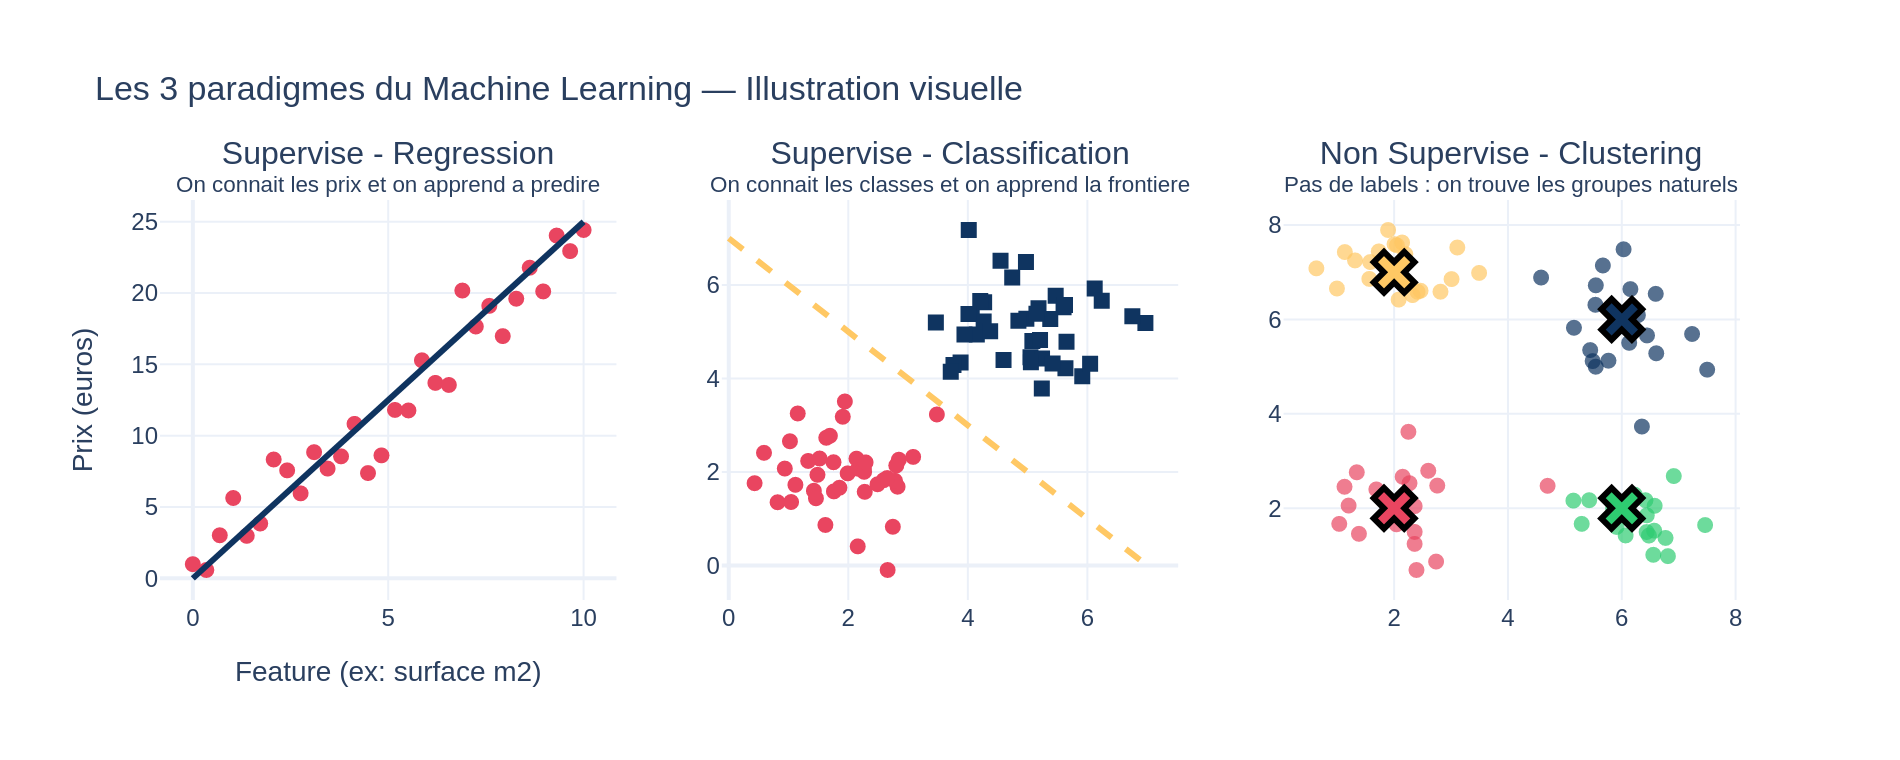

Lecture :
  GAUCHE  : chaque point = une maison. La ligne = ce que le modele predit.
  MILIEU  : les deux formes = les deux classes. La ligne = frontiere de decision apprise.
  DROITE  : les X = centroïdes. Les couleurs = groupes trouves automatiquement.


In [2]:
np.random.seed(42)
fig = make_subplots(rows=1, cols=3,
    subplot_titles=(
        "Supervise - Regression<br><sup>On connait les prix et on apprend a predire</sup>",
        "Supervise - Classification<br><sup>On connait les classes et on apprend la frontiere</sup>",
        "Non Supervise - Clustering<br><sup>Pas de labels : on trouve les groupes naturels</sup>"
    ))

# Regression
x_reg = np.linspace(0, 10, 30)
y_reg = 2.5*x_reg + np.random.normal(0, 2, 30)
fig.add_trace(go.Scatter(x=x_reg, y=y_reg, mode="markers",
    marker=dict(color=COLORS["primary"], size=8), showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(x=[0,10], y=[0,25], mode="lines",
    line=dict(color=COLORS["secondary"], width=3), showlegend=False), row=1, col=1)

# Classification
n = 40
x1 = np.random.normal(2, 0.8, n); y1 = np.random.normal(2, 0.8, n)
x2 = np.random.normal(5, 0.8, n); y2 = np.random.normal(5, 0.8, n)
fig.add_trace(go.Scatter(x=x1, y=y1, mode="markers",
    marker=dict(color=COLORS["primary"], size=8, symbol="circle"), showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=x2, y=y2, mode="markers",
    marker=dict(color=COLORS["secondary"], size=8, symbol="square"), showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=[0,7], y=[7,0], mode="lines",
    line=dict(color=COLORS["accent"], width=3, dash="dash"), showlegend=False), row=1, col=2)

# Clustering
for i, (cx,cy) in enumerate([(2,2),(6,6),(2,7),(6,2)]):
    xc = np.random.normal(cx, 0.7, 20); yc = np.random.normal(cy, 0.7, 20)
    fig.add_trace(go.Scatter(x=xc, y=yc, mode="markers",
        marker=dict(color=PALETTE[i], size=8, opacity=0.7), showlegend=False), row=1, col=3)
    fig.add_trace(go.Scatter(x=[cx], y=[cy], mode="markers",
        marker=dict(color=PALETTE[i], size=18, symbol="x",
                    line=dict(width=3, color="black")), showlegend=False), row=1, col=3)

fig.update_layout(height=380, template="plotly_white",
    title="Les 3 paradigmes du Machine Learning — Illustration visuelle")
fig.update_xaxes(title_text="Feature (ex: surface m2)", row=1, col=1)
fig.update_yaxes(title_text="Prix (euros)", row=1, col=1)
fig.show()
print("Lecture :")
print("  GAUCHE  : chaque point = une maison. La ligne = ce que le modele predit.")
print("  MILIEU  : les deux formes = les deux classes. La ligne = frontiere de decision apprise.")
print("  DROITE  : les X = centroïdes. Les couleurs = groupes trouves automatiquement.")

---
<div style="background:linear-gradient(90deg,#0f3460,#0a2540);padding:18px 24px;border-radius:10px;color:white;margin:20px 0;">
<h1 style="margin:0;">📈 Partie 2 — Régression : Prédire des Valeurs Continues</h1>
</div>

## 2.1 — Qu'est-ce que la régression ?

La régression répond à la question : **"Quelle valeur numérique puis-je prédire ?"**

La cible est un **nombre réel** (prix, température, durée, énergie...), contrairement à la classification qui prédit une catégorie.

### Exemples industriels
- Prédire la **consommation énergétique** d'un bâtiment → optimiser le chauffage
- Prédire la **durée de vie restante** d'un composant → maintenance préventive
- Prédire le **prix de vente** d'un produit → stratégie commerciale
- Prédire la **charge réseau** dans 1h → allouer des ressources

---

## 2.2 — Régression Linéaire : le modèle de base

### L'idée intuitive

On cherche la **droite (ou le plan) qui passe au mieux** à travers les données.

En 1D : `y = a × x + b`
- `y` = valeur à prédire (ex: prix d'une maison)
- `x` = variable explicative (ex: surface en m²)
- `a` = pente (coefficient) : combien le prix augmente par m² supplémentaire
- `b` = ordonnée à l'origine : prix de base

En multi-dimensionnel (plusieurs features) :
`y = a₁×x₁ + a₂×x₂ + ... + aₙ×xₙ + b`

### Comment ça apprend ?

L'algorithme cherche les coefficients `a₁, a₂, ..., aₙ` qui **minimisent la somme des erreurs au carré** entre les prédictions et les valeurs réelles. C'est le critère des **Moindres Carrés Ordinaires (MCO)**.

---

## 2.3 — Ridge et Lasso : régularisation contre l'overfitting

Avec beaucoup de variables, la régression linéaire peut **overfitter** : elle s'adapte trop au bruit des données d'entraînement.

### Ridge (L2) — "Shrinkage"
Ajoute une **pénalité proportionnelle au carré des coefficients** dans la fonction de coût.
- Effet : tous les coefficients sont réduits mais restent non nuls
- Utile quand toutes les variables sont potentiellement utiles

### Lasso (L1) — "Sélection de variables"
Ajoute une **pénalité proportionnelle à la valeur absolue des coefficients**.
- Effet : force certains coefficients à devenir exactement **zéro** → sélection automatique de variables
- Utile quand on pense que peu de variables sont vraiment importantes

### Le paramètre α (alpha)
- `α = 0` : pas de régularisation (= régression linéaire classique)
- `α grand` : forte régularisation, coefficients très petits, modèle simple
- `α petit` : faible régularisation, proche de la régression linéaire

---

## 2.4 — Les métriques d'évaluation en régression

### Comment mesurer si un modèle est bon ?

**R² (Coefficient de Détermination)**

R² mesure la proportion de la variance des données que le modèle explique.

- R² = 1.0 → prédiction parfaite
- R² = 0.0 → le modèle ne fait pas mieux que de prédire la moyenne
- R² < 0  → le modèle est pire que la moyenne (très mauvais)

*Exemple :* R² = 0.75 signifie que le modèle explique 75% des variations de prix entre les maisons.

**RMSE (Root Mean Square Error)**

RMSE = racine carrée de la moyenne des erreurs au carré.

*Comment le lire :* RMSE est dans la même unité que la variable cible. Si on prédit des prix en euros et RMSE = 5000€, l'erreur typique est de 5000€ par prédiction.

*Particularité :* RMSE **pénalise fortement les grandes erreurs** (à cause du carré). Préférer RMSE quand les erreurs importantes coûtent cher.

**MAE (Mean Absolute Error)**

MAE = moyenne des valeurs absolues des erreurs.

*Comment le lire :* MAE est aussi dans l'unité de la cible. Si MAE = 3000€, en moyenne on se trompe de 3000€.

*Différence avec RMSE :* MAE est **robuste aux valeurs aberrantes** — une très grande erreur n'a pas plus d'impact que plusieurs petites.

**MAPE (Mean Absolute Percentage Error)**

MAPE = moyenne des erreurs relatives en pourcentage.

*Formule :* Pour chaque prédiction, calculer `|valeur_réelle - valeur_prédite| / valeur_réelle × 100`, puis faire la moyenne.

*Exemple concret :* Si la vraie valeur est 100€ et qu'on prédit 90€, l'erreur est 10%. Si on prédit 1100€ au lieu de 1000€, l'erreur est aussi 10%. MAPE traite ces deux erreurs de la même façon, ce qui permet de **comparer des produits d'échelles très différentes**.

- MAPE < 10% = excellent
- MAPE 10-20% = acceptable
- MAPE > 20% = à améliorer

### Quelle métrique choisir ?

| Situation | Métrique recommandée |
|-----------|---------------------|
| Comparer des modèles | R² |
| Erreurs importantes sont catastrophiques | RMSE |
| Données avec outliers | MAE |
| Comparer plusieurs produits/scales | MAPE |
| Toujours en pratique | R² + RMSE ensemble |


### Illustration — Underfitting, Good Fit, Overfitting

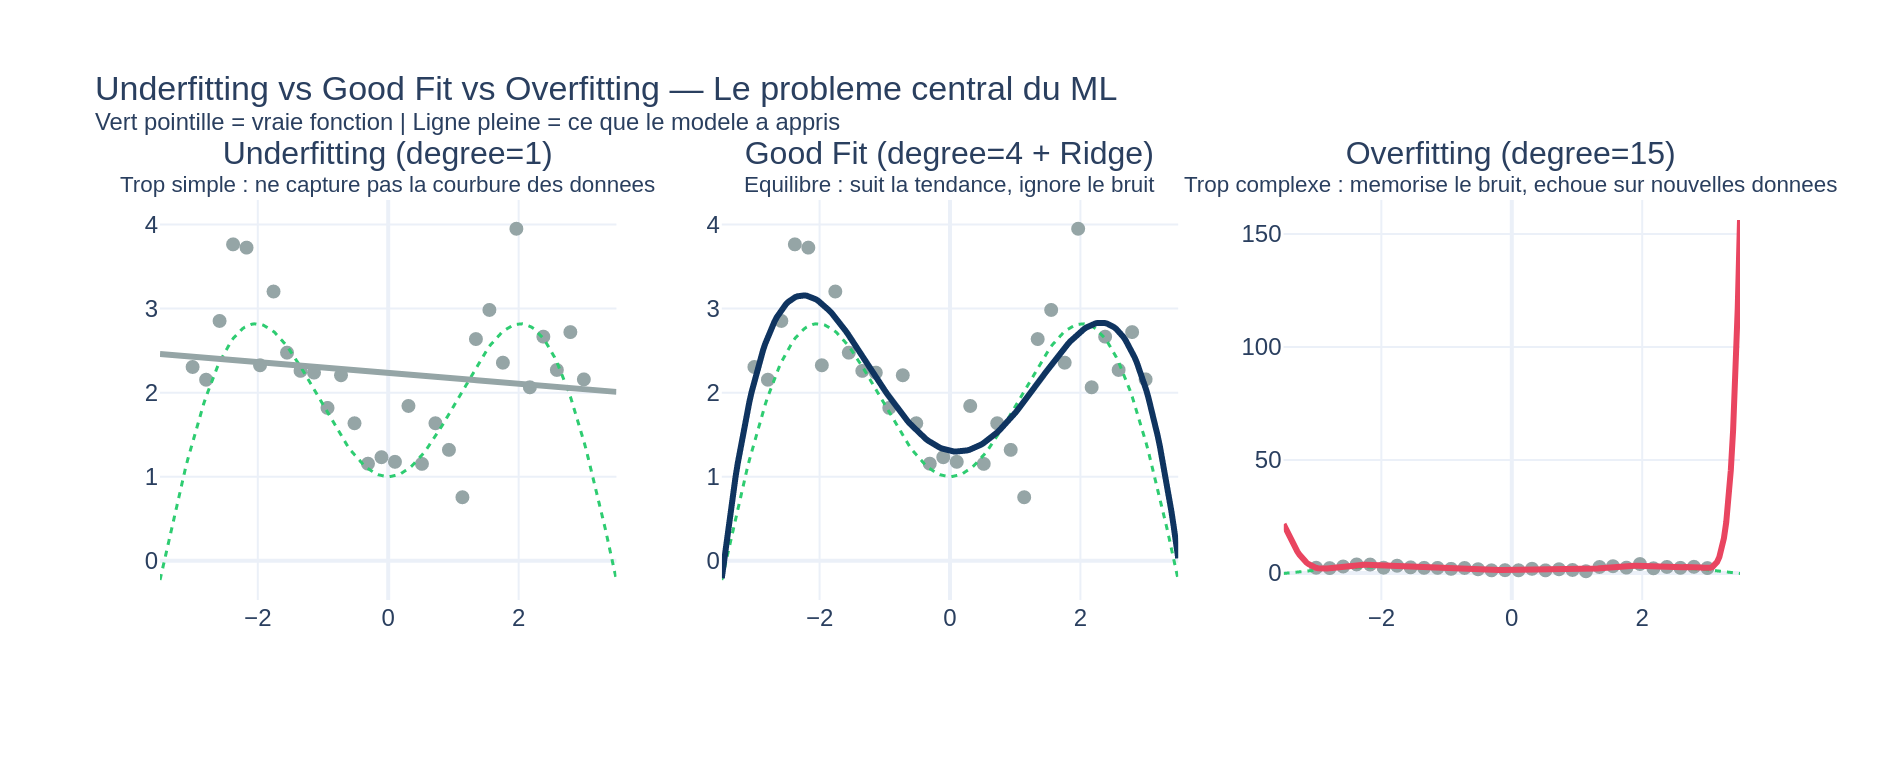

Underfitting : la droite ne suit pas la courbure — trop simple
Good Fit     : le modele suit la tendance sans coller au bruit — ideal
Overfitting  : le modele fait des zigzags pour passer par chaque point — trop complexe

La regularisation Ridge (milieu) penalise les coefficients eleves
→ empeche le modele de trop coller aux donnees d'entrainement


In [3]:
np.random.seed(0)
x_raw  = np.linspace(-3, 3, 30)
y_true = np.sin(x_raw)*x_raw + 1
y_data = y_true + np.random.normal(0, 0.5, 30)
x_plot = np.linspace(-3.5, 3.5, 200)
y_ref  = np.sin(x_plot)*x_plot + 1

fig = make_subplots(rows=1, cols=3,
    subplot_titles=(
        "Underfitting (degree=1)<br><sup>Trop simple : ne capture pas la courbure des donnees</sup>",
        "Good Fit (degree=4 + Ridge)<br><sup>Equilibre : suit la tendance, ignore le bruit</sup>",
        "Overfitting (degree=15)<br><sup>Trop complexe : memorise le bruit, echoue sur nouvelles donnees</sup>"
    ))

X_raw  = x_raw.reshape(-1,1)
X_plot = x_plot.reshape(-1,1)
for col, (deg, use_ridge) in enumerate([(1,False),(4,True),(15,False)], 1):
    from sklearn.linear_model import Ridge as R_
    est = R_(alpha=1.0) if use_ridge else LinearRegression()
    pipe = Pipeline([("poly", PolynomialFeatures(deg)), ("m", est)])
    pipe.fit(X_raw, y_data)
    y_hat = pipe.predict(X_plot)
    col_line = [COLORS["neutral"], COLORS["secondary"], COLORS["primary"]][col-1]
    fig.add_trace(go.Scatter(x=x_raw, y=y_data, mode="markers",
        marker=dict(color=COLORS["neutral"], size=7), showlegend=False), row=1, col=col)
    fig.add_trace(go.Scatter(x=x_plot, y=y_ref, mode="lines",
        line=dict(color=COLORS["success"], width=1.5, dash="dot"), showlegend=False), row=1, col=col)
    fig.add_trace(go.Scatter(x=x_plot, y=y_hat, mode="lines",
        line=dict(color=col_line, width=3), showlegend=False), row=1, col=col)

fig.update_layout(height=380, template="plotly_white",
    title="Underfitting vs Good Fit vs Overfitting — Le probleme central du ML<br>"
          "<sup>Vert pointille = vraie fonction | Ligne pleine = ce que le modele a appris</sup>")
fig.show()
print("Underfitting : la droite ne suit pas la courbure — trop simple")
print("Good Fit     : le modele suit la tendance sans coller au bruit — ideal")
print("Overfitting  : le modele fait des zigzags pour passer par chaque point — trop complexe")
print()
print("La regularisation Ridge (milieu) penalise les coefficients eleves")
print("→ empeche le modele de trop coller aux donnees d'entrainement")

In [4]:
from sklearn import datasets

housing = datasets.fetch_california_housing()
X_h = pd.DataFrame(housing.data, columns=housing.feature_names)
y_h = housing.target

feat_desc = {
    "MedInc":"Revenu median du foyer (x$10k)",
    "HouseAge":"Age median des maisons (annees)",
    "AveRooms":"Nb moyen de pieces par logement",
    "AveBedrms":"Nb moyen de chambres",
    "Population":"Population du quartier",
    "AveOccup":"Nb moyen d'occupants",
    "Latitude":"Latitude geographique",
    "Longitude":"Longitude geographique",
}
X_tr, X_te, y_tr, y_te = train_test_split(X_h, y_h, test_size=0.2, random_state=42)
print(f"Dataset California Housing : {X_h.shape[0]:,} logements | {X_h.shape[1]} features")
print()
print("Description des features :")
for feat, desc in feat_desc.items():
    print(f"  {feat:<12} : {desc}")

Dataset California Housing : 20,640 logements | 8 features

Description des features :
  MedInc       : Revenu median du foyer (x$10k)
  HouseAge     : Age median des maisons (annees)
  AveRooms     : Nb moyen de pieces par logement
  AveBedrms    : Nb moyen de chambres
  Population   : Population du quartier
  AveOccup     : Nb moyen d'occupants
  Latitude     : Latitude geographique
  Longitude    : Longitude geographique


In [5]:
models_reg = {
    "Regression Lineaire": LinearRegression(),
    "Ridge (alpha=1)":     Ridge(alpha=1.0),
    "Lasso (alpha=0.05)":  Lasso(alpha=0.05),
}

results_reg = {}
for name, model in models_reg.items():
    pipe = Pipeline([("sc", StandardScaler()), ("m", model)])
    pipe.fit(X_tr, y_tr)
    yp   = pipe.predict(X_te)
    cv   = cross_val_score(pipe, X_h, y_h, cv=5, scoring="r2")
    rmse = np.sqrt(mean_squared_error(y_te, yp))
    mae  = mean_absolute_error(y_te, yp)
    mape = np.mean(np.abs((y_te - yp) / y_te)) * 100
    results_reg[name] = {
        "R2":pipe.__class__,"r2":round(r2_score(y_te,yp),3),
        "rmse":round(rmse,3),"mae":round(mae,3),"mape":round(mape,1),
        "cv_m":round(cv.mean(),3),"cv_s":round(cv.std(),3),
        "pipe":pipe,"yp":yp,
    }

print("COMPARAISON DES MODELES DE REGRESSION")
print("="*72)
print(f"{'Modele':<24} {'R2':>5} {'RMSE':>7} {'MAE':>6} {'MAPE%':>6} {'CV R2':>7} {'CV Std':>7}")
print("-"*72)
for n,r in results_reg.items():
    print(f"{n:<24} {r['r2']:>5.3f} {r['rmse']:>7.3f} {r['mae']:>6.3f} {r['mape']:>6.1f} {r['cv_m']:>7.3f} {r['cv_s']:>7.3f}")
print()
print("Lecture des colonnes :")
print("  R2     : 1=parfait, 0=inutile. 0.60 = le modele explique 60% de la variance des prix.")
print("  RMSE   : erreur typique en $100k. RMSE=0.73 = on se trompe de 73 000$ en moyenne.")
print("  MAE    : erreur absolue moyenne. Moins sensible aux outliers que RMSE.")
print("  MAPE%  : erreur relative en %. MAPE=35% = on se trompe en moyenne de 35% du vrai prix.")
print("           Universel : permet de comparer des produits d'echelles differentes.")
print("  CV R2  : R2 moyen sur 5 folds. Plus fiable qu'un seul split train/test.")
print("  CV Std : ecart-type entre les 5 folds. Petit = modele stable.")

COMPARAISON DES MODELES DE REGRESSION
Modele                      R2    RMSE    MAE  MAPE%   CV R2  CV Std
------------------------------------------------------------------------
Regression Lineaire      0.576   0.746  0.533   32.0   0.553   0.062
Ridge (alpha=1)          0.576   0.746  0.533   32.0   0.553   0.062
Lasso (alpha=0.05)       0.531   0.784  0.582   36.1   0.477   0.068

Lecture des colonnes :
  R2     : 1=parfait, 0=inutile. 0.60 = le modele explique 60% de la variance des prix.
  RMSE   : erreur typique en $100k. RMSE=0.73 = on se trompe de 73 000$ en moyenne.
  MAE    : erreur absolue moyenne. Moins sensible aux outliers que RMSE.
  MAPE%  : erreur relative en %. MAPE=35% = on se trompe en moyenne de 35% du vrai prix.
           Universel : permet de comparer des produits d'echelles differentes.
  CV R2  : R2 moyen sur 5 folds. Plus fiable qu'un seul split train/test.
  CV Std : ecart-type entre les 5 folds. Petit = modele stable.


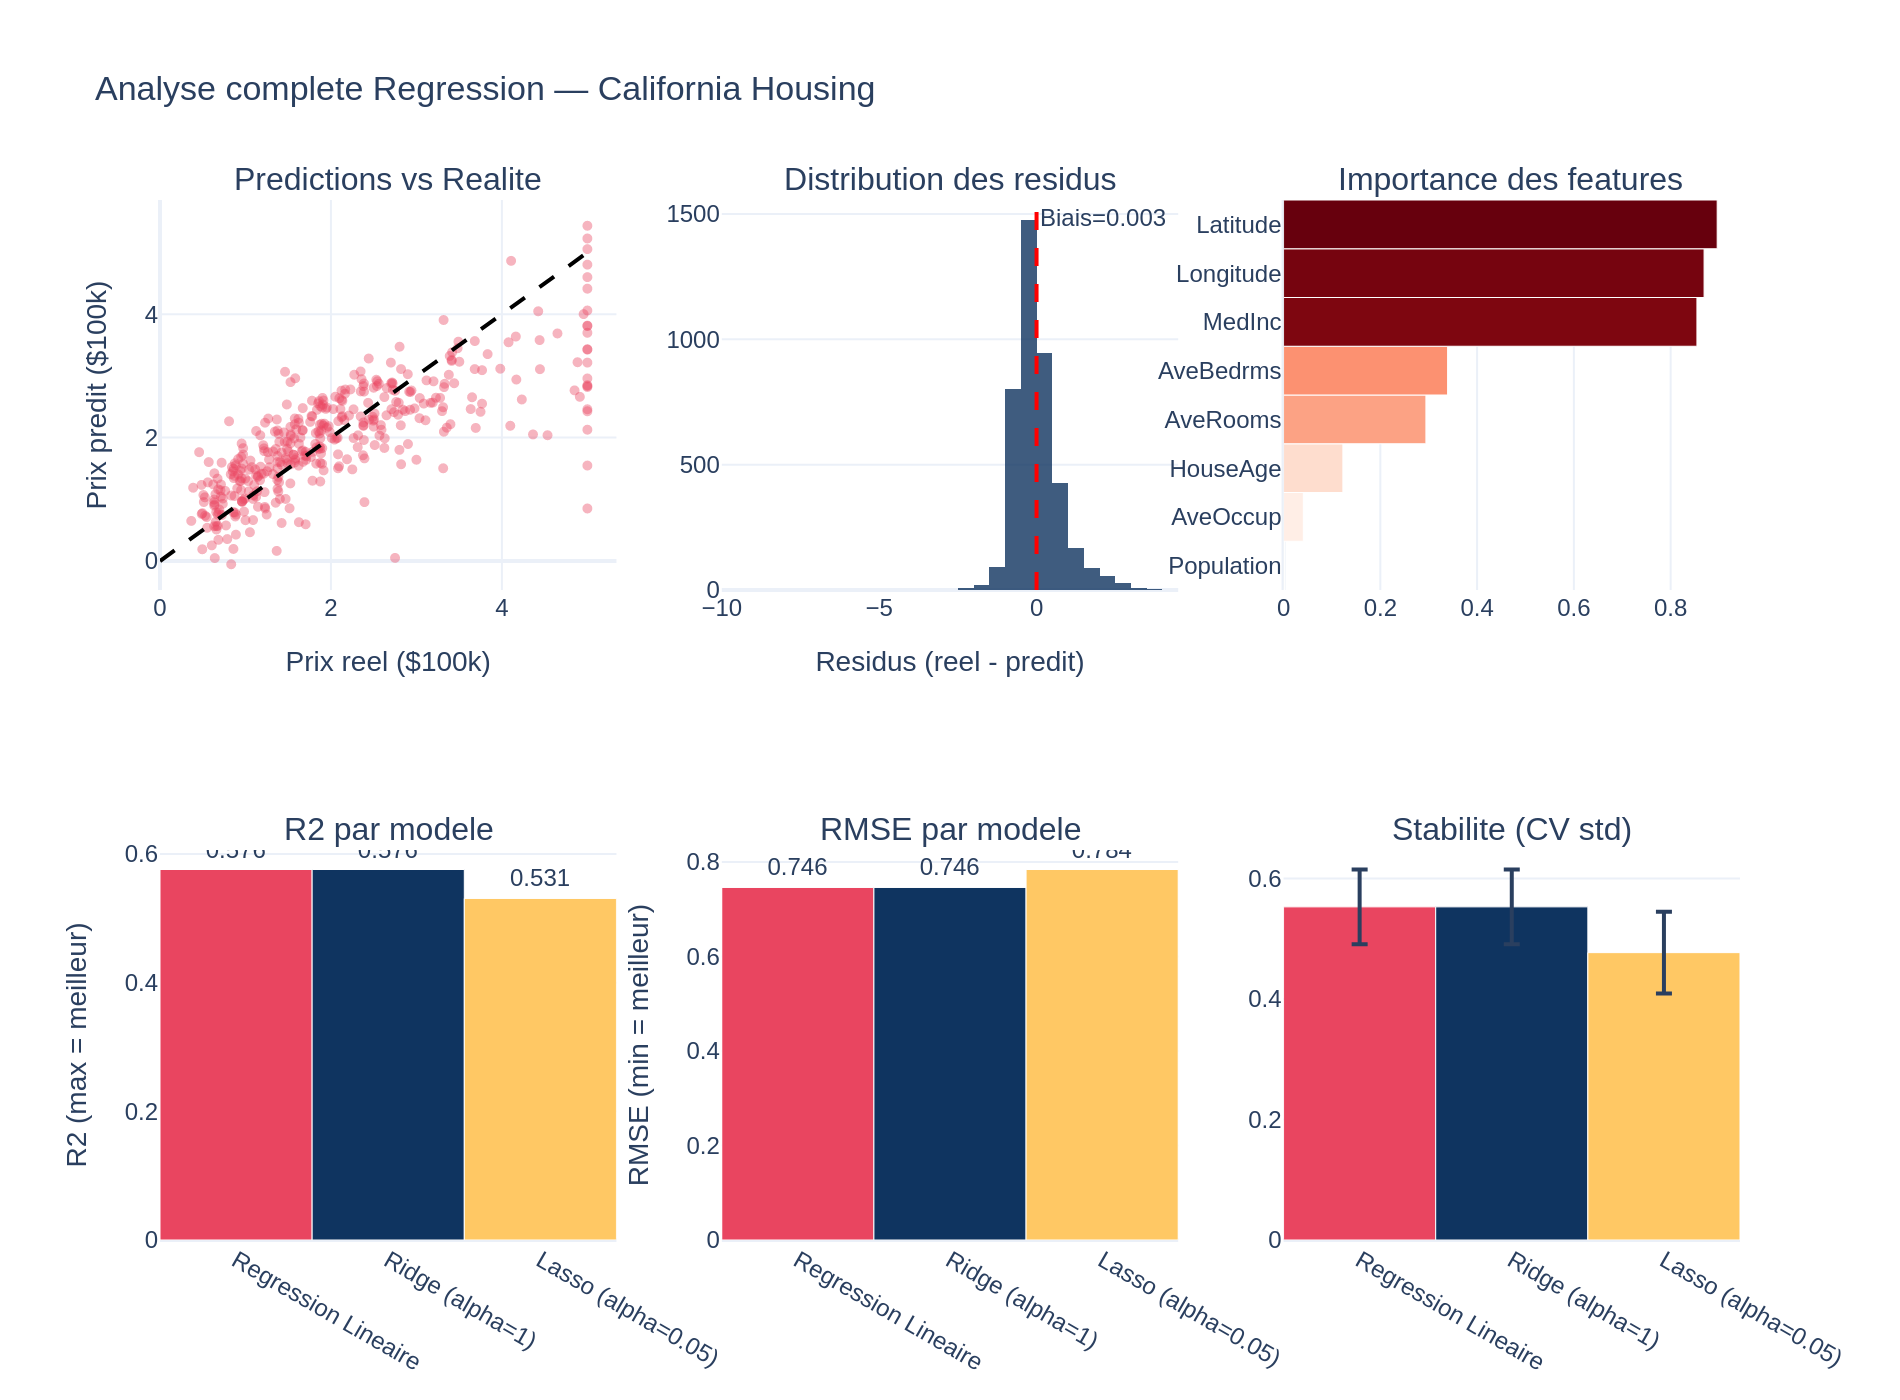

Lecture des graphes :
  Haut gauche : points sur la diagonale = prediction parfaite.
                Points eloignes = erreurs. Le modele sous-estime les maisons tres cheres.
  Haut milieu : residus centres sur 0 = pas de biais systematique.
  Haut droite : MedInc domine — le revenu predit le mieux le prix du quartier.


In [6]:
best_name = "Ridge (alpha=1)"
best_pipe = results_reg[best_name]["pipe"]
yp_r      = results_reg[best_name]["yp"]
residuals = y_te - yp_r

fig = make_subplots(rows=2, cols=3,
    subplot_titles=(
        "Predictions vs Realite",
        "Distribution des residus",
        "Importance des features",
        "R2 par modele",
        "RMSE par modele",
        "Stabilite (CV std)",
    ))

idx = np.random.choice(len(y_te), 400, replace=False)
fig.add_trace(go.Scatter(x=y_te[idx], y=yp_r[idx], mode="markers",
    marker=dict(color=COLORS["primary"], size=5, opacity=0.4),
    hovertemplate="Reel: $%{x:.2f}x100k<br>Predit: $%{y:.2f}x100k"), row=1, col=1)
fig.add_trace(go.Scatter(x=[0,5], y=[0,5], mode="lines",
    line=dict(color="black", dash="dash", width=2)), row=1, col=1)
fig.add_trace(go.Histogram(x=residuals, nbinsx=50,
    marker_color=COLORS["secondary"], opacity=0.8), row=1, col=2)
fig.add_vline(x=0, line_dash="dash", line_color="red",
    annotation_text=f"Biais={residuals.mean():.3f}", row=1, col=2)

coefs = pd.Series(np.abs(best_pipe.named_steps["m"].coef_),
                  index=housing.feature_names).sort_values()
fig.add_trace(go.Bar(x=coefs.values, y=coefs.index, orientation="h",
    marker=dict(color=coefs.values, colorscale="Reds", showscale=False)), row=1, col=3)

names_r = list(results_reg.keys())
fig.add_trace(go.Bar(x=names_r, y=[results_reg[n]["r2"] for n in names_r],
    marker_color=PALETTE[:3], text=[f"{results_reg[n]['r2']:.3f}" for n in names_r],
    textposition="outside"), row=2, col=1)
fig.add_trace(go.Bar(x=names_r, y=[results_reg[n]["rmse"] for n in names_r],
    marker_color=PALETTE[:3], text=[f"{results_reg[n]['rmse']:.3f}" for n in names_r],
    textposition="outside"), row=2, col=2)
fig.add_trace(go.Bar(x=names_r, y=[results_reg[n]["cv_m"] for n in names_r],
    error_y=dict(type="data", array=[results_reg[n]["cv_s"] for n in names_r]),
    marker_color=PALETTE[:3]), row=2, col=3)

fig.update_layout(height=700, template="plotly_white", showlegend=False,
    title="Analyse complete Regression — California Housing")
fig.update_xaxes(title_text="Prix reel ($100k)", row=1, col=1)
fig.update_yaxes(title_text="Prix predit ($100k)", row=1, col=1)
fig.update_xaxes(title_text="Residus (reel - predit)", row=1, col=2)
fig.update_yaxes(title_text="R2 (max = meilleur)", row=2, col=1)
fig.update_yaxes(title_text="RMSE (min = meilleur)", row=2, col=2)
fig.show()

print("Lecture des graphes :")
print("  Haut gauche : points sur la diagonale = prediction parfaite.")
print("                Points eloignes = erreurs. Le modele sous-estime les maisons tres cheres.")
print("  Haut milieu : residus centres sur 0 = pas de biais systematique.")
print("  Haut droite : MedInc domine — le revenu predit le mieux le prix du quartier.")

---
<div style="background:linear-gradient(90deg,#e94560,#9b2335);padding:18px 24px;border-radius:10px;color:white;margin:20px 0;">
<h1 style="margin:0;">🎯 Partie 3 — Classification : Décider entre des Catégories</h1>
</div>

## 3.1 — Qu'est-ce que la classification ?

La classification répond à la question : **"À quelle catégorie appartient cet exemple ?"**

La cible est une **classe discrète** (panne/normal, spam/ham, A/B/C...).

### Classification binaire vs multi-classes
- **Binaire :** 2 classes (oui/non, fraude/légitime, malade/sain)
- **Multi-classes :** 3+ classes (chat/chien/oiseau, A/B/C/D, type de défaut 1/2/3/4)

### Exemples industriels
- **Contrôle qualité :** pièce conforme ou défectueuse
- **Maintenance :** type de panne (électrique, mécanique, usure, surchauffe)
- **Finance :** transaction frauduleuse ou légitime
- **Médical :** image tumorale ou saine
- **NLP :** email spam ou normal

---

## 3.2 — Régression Logistique : le modèle de base

### L'idée intuitive

Malgré son nom, c'est un **classificateur**, pas un modèle de régression.

Elle calcule une **probabilité** d'appartenir à la classe positive, puis compare à un seuil (souvent 0.5) pour décider.

La fonction qui transforme un score en probabilité s'appelle la **fonction sigmoïde** : elle prend n'importe quel nombre et le transforme en valeur entre 0 et 1.

**Avantages :** rapide, interprétable, donne des probabilités calibrées
**Limites :** frontière de décision linéaire uniquement

---

## 3.3 — Arbres de Décision

### L'idée intuitive

Un arbre de décision, c'est comme un **jeu de 20 questions** : on pose des questions successives sur les features pour arriver à une décision.

```
Est-ce que temperature > 85°C ?
    OUI → Est-ce que vibration > 3.0 mm/s ?
                OUI → PANNE (confiance: 94%)
                NON → SURVEILLANCE (confiance: 71%)
    NON → NORMAL (confiance: 89%)
```

**Avantages :** très interprétable, visible, pas besoin de normaliser les données
**Limites :** overfit facilement (arbre trop profond = mémorisation)

**Paramètre clé :** `max_depth` — limiter la profondeur évite l'overfitting.

---

## 3.4 — Random Forest (Forêt Aléatoire)

### L'idée intuitive : la sagesse des foules

Au lieu d'un seul arbre, on entraîne **100 arbres différents** (chacun sur un sous-ensemble aléatoire des données et des features), puis on fait **voter la majorité**.

> **Analogie :** Plutôt que de demander son avis à un seul expert (qui peut se tromper), on demande à 100 experts indépendants et on suit la majorité.

**Pourquoi ça marche mieux ?** Les erreurs individuelles de chaque arbre se compensent. Le vote majoritaire est plus robuste qu'un seul avis.

**Avantages :** robuste, peu d'hyperparamètres à régler, donne l'importance des features
**Limites :** plus lent qu'un seul arbre, moins interprétable

---

## 3.5 — Gradient Boosting

### L'idée intuitive : apprendre de ses erreurs

Le Gradient Boosting construit des arbres **en séquence** : chaque nouvel arbre apprend à corriger les erreurs du précédent.

1. Arbre 1 : prédit grossièrement, fait des erreurs
2. Arbre 2 : se concentre sur les exemples mal classés par Arbre 1
3. Arbre 3 : corrige les erreurs restantes d'Arbre 2...
4. Et ainsi de suite pour N arbres

**Résultat :** modèle très précis, souvent champion des compétitions Kaggle
**Variants populaires :** XGBoost, LightGBM, CatBoost

**Avantages :** performances état de l'art sur données tabulaires
**Limites :** lent à entraîner, beaucoup d'hyperparamètres, peut overfitter

---

## 3.6 — SVM (Support Vector Machine)

### L'idée intuitive : la marge maximale

Le SVM cherche la **frontière de décision qui maximise la distance** (marge) entre les deux classes.

> **Analogie :** Tracer une route entre deux villes en passant le plus loin possible de chaque bâtiment des deux côtés.

**Kernel trick :** le SVM peut utiliser des **fonctions noyau** (RBF, polynomial) pour tracer des frontières non-linéaires en projetant les données dans un espace de dimension supérieure.

**Avantages :** efficace en haute dimension, robuste aux outliers
**Limites :** lent sur grands datasets, nécessite un scaling

---

## 3.7 — Les métriques d'évaluation en classification

### Le problème de l'accuracy

> **Piège classique :** Si 95% des transactions sont normales et 5% sont frauduleuses, un modèle qui dit **toujours "normal"** a 95% d'accuracy... mais est complètement inutile.

C'est pourquoi on a besoin d'autres métriques.

### La matrice de confusion : comprendre les erreurs

Pour une classification binaire (ex: panne / normal) :

```
                    PRÉDIT Normal    PRÉDIT Panne
RÉEL Normal    [  Vrai Négatif  ]  [ Faux Positif ]
RÉEL Panne     [ Faux Négatif  ]  [  Vrai Positif ]
```

- **Vrai Négatif (TN)** : normal prédit normal ✅
- **Vrai Positif (TP)** : panne prédite panne ✅
- **Faux Positif (FP)** : normal prédit panne → fausse alarme ⚠️
- **Faux Négatif (FN)** : panne prédite normale → panne manquée ❌ (souvent le pire cas)

### Les 4 métriques principales

**Accuracy** = (TP + TN) / Total
→ % de prédictions correctes. Trompeuse si classes déséquilibrées.

**Précision** = TP / (TP + FP)
→ "Parmi toutes mes alarmes, combien sont de vraies pannes ?"
→ Maximiser quand les fausses alarmes coûtent cher (arrêts inutiles)

**Rappel (Recall/Sensibilité)** = TP / (TP + FN)
→ "Parmi toutes les vraies pannes, combien ai-je détectées ?"
→ Maximiser quand rater une vraie panne est catastrophique

**F1-Score** = 2 × Précision × Rappel / (Précision + Rappel)
→ Compromis entre Précision et Rappel. Idéal pour classes déséquilibrées.

### La courbe ROC et l'AUC

La courbe ROC trace le Rappel (axe Y) vs le Taux de Faux Positifs (axe X) pour tous les seuils de décision possibles.

**AUC (Area Under Curve)** = aire sous la courbe ROC
- AUC = 1.0 → modèle parfait
- AUC = 0.5 → modèle aléatoire (inutile)
- AUC > 0.9 → excellent pour usage industriel

**L'intérêt :** permet de choisir le seuil selon le coût métier. Exemple pour une détection de panne :
- Si arrêt préventif coûte 1000€ et panne non détectée coûte 50000€ → abaisser le seuil pour maximiser le rappel


In [7]:
np.random.seed(42)
n = 1500
temp      = np.random.normal(75, 10, n)
vibration = np.random.normal(2.0, 0.5, n)
pression  = np.random.normal(4.5, 0.8, n)
courant   = np.random.normal(12.0, 1.5, n)
panne  = (temp > 90) | (vibration > 3.2) | ((temp > 82) & (courant > 14.5))
labels = np.clip(panne.astype(int) + np.random.binomial(1, 0.04, n), 0, 1)
X_m = pd.DataFrame({"temperature":temp,"vibration":vibration,
                     "pression":pression,"courant":courant})
y_m = labels
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_m, y_m, test_size=0.2, random_state=42, stratify=y_m)

print(f"Dataset capteurs machine : {n} mesures")
print(f"  Normal : {(labels==0).sum()} ({(labels==0).mean()*100:.1f}%)")
print(f"  Panne  : {(labels==1).sum()} ({(labels==1).mean()*100:.1f}%)")
print()
print("Attention au desequilibre des classes :")
print(f"  Un modele naif 'toujours Normal' aurait {(labels==0).mean()*100:.0f}% d'accuracy")
print("  mais ne detecterait AUCUNE panne → l'accuracy est ici une mauvaise metrique.")
print("  Utiliser F1-Score et Rappel comme metriques principales.")

Dataset capteurs machine : 1500 mesures
  Normal : 1308 (87.2%)
  Panne  : 192 (12.8%)

Attention au desequilibre des classes :
  Un modele naif 'toujours Normal' aurait 87% d'accuracy
  mais ne detecterait AUCUNE panne → l'accuracy est ici une mauvaise metrique.
  Utiliser F1-Score et Rappel comme metriques principales.


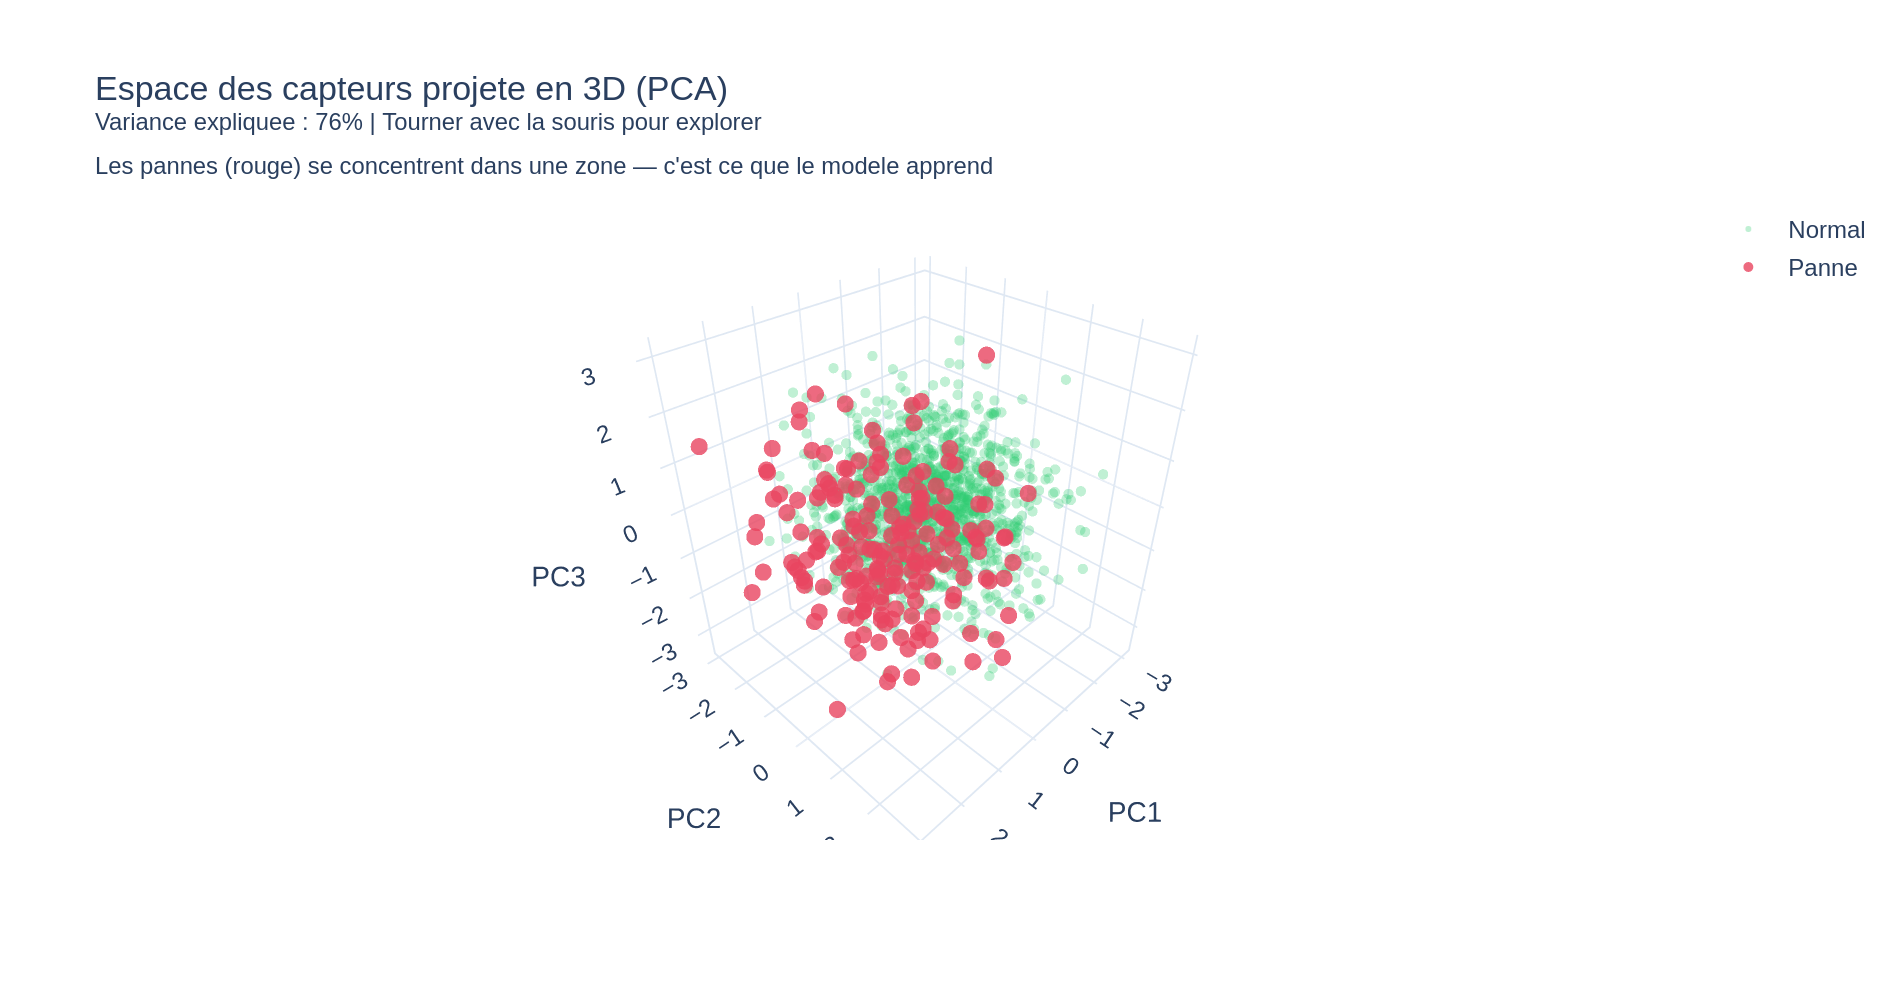

In [8]:
Xs_m = StandardScaler().fit_transform(X_m)
pca3 = PCA(n_components=3)
X3_m = pca3.fit_transform(Xs_m)
var3 = pca3.explained_variance_ratio_
fig = go.Figure(data=[
    go.Scatter3d(x=X3_m[y_m==0,0],y=X3_m[y_m==0,1],z=X3_m[y_m==0,2],
        mode="markers",name="Normal",marker=dict(size=3,color=COLORS["success"],opacity=0.3)),
    go.Scatter3d(x=X3_m[y_m==1,0],y=X3_m[y_m==1,1],z=X3_m[y_m==1,2],
        mode="markers",name="Panne",marker=dict(size=5,color=COLORS["primary"],opacity=0.8))
])
fig.update_layout(
    title=(f"Espace des capteurs projete en 3D (PCA)<br>"
           f"<sup>Variance expliquee : {var3.sum()*100:.0f}% | "
           "Tourner avec la souris pour explorer<br>"
           "Les pannes (rouge) se concentrent dans une zone — c'est ce que le modele apprend</sup>"),
    scene=dict(xaxis_title="PC1",yaxis_title="PC2",zaxis_title="PC3"),
    height=500, template="plotly_white")
fig.show()

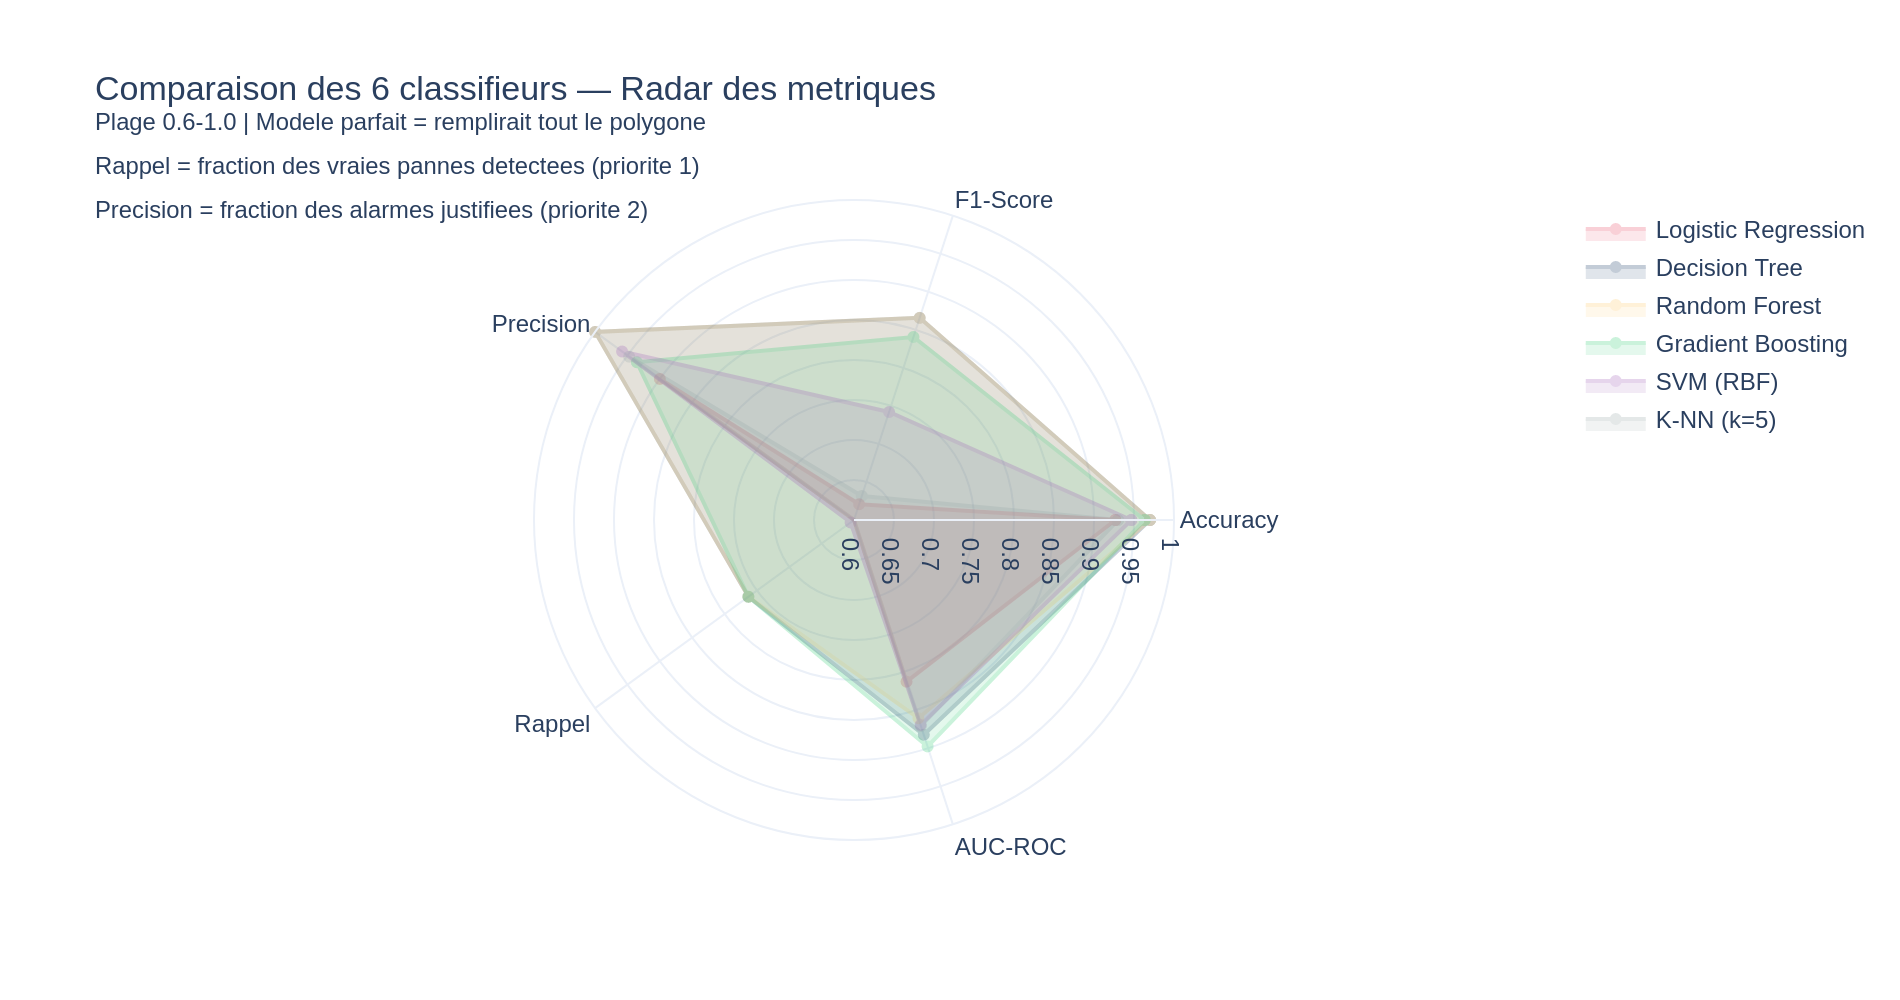

Modele                     Accuracy      F1  Precision   Rappel     AUC
----------------------------------------------------------------------
Decision Tree                 0.970   0.866      1.000    0.763   0.882
Random Forest                 0.970   0.866      1.000    0.763   0.861
Gradient Boosting             0.963   0.841      0.935    0.763   0.898
SVM (RBF)                     0.947   0.742      0.958    0.605   0.869
K-NN (k=5)                    0.930   0.632      0.947    0.474   0.871
Logistic Regression           0.927   0.621      0.900    0.474   0.812


In [9]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)":           SVC(kernel="rbf", probability=True),
    "K-NN (k=5)":          KNeighborsClassifier(n_neighbors=5),
}
clf_results = {}
for name, clf in classifiers.items():
    pipe = Pipeline([("sc", StandardScaler()), ("clf", clf)])
    pipe.fit(X_tr_m, y_tr_m)
    yp   = pipe.predict(X_te_m)
    yprob= pipe.predict_proba(X_te_m)[:,1] if hasattr(clf,"predict_proba") else None
    fpr_,tpr_,_ = roc_curve(y_te_m,yprob) if yprob is not None else ([0,1],[0,1],None)
    clf_results[name] = {"acc":accuracy_score(y_te_m,yp),"f1":f1_score(y_te_m,yp),
        "prec":precision_score(y_te_m,yp),"rec":recall_score(y_te_m,yp),
        "auc":auc(fpr_,tpr_),"pipe":pipe,"yp":yp,"yprob":yprob,"fpr":fpr_,"tpr":tpr_}

mets = ["acc","f1","prec","rec","auc"]
met_labels = ["Accuracy","F1-Score","Precision","Rappel","AUC-ROC"]
fig = go.Figure()
for i,(name,r) in enumerate(clf_results.items()):
    vals = [r[m] for m in mets]+[r[mets[0]]]
    fig.add_trace(go.Scatterpolar(r=vals,theta=met_labels+[met_labels[0]],
        fill="toself",opacity=0.25,name=name,line=dict(color=PALETTE[i])))
fig.update_layout(polar=dict(radialaxis=dict(visible=True,range=[0.6,1.0])),
    title="Comparaison des 6 classifieurs — Radar des metriques<br>"
          "<sup>Plage 0.6-1.0 | Modele parfait = remplirait tout le polygone<br>"
          "Rappel = fraction des vraies pannes detectees (priorite 1)<br>"
          "Precision = fraction des alarmes justifiees (priorite 2)</sup>",
    height=500,template="plotly_white")
fig.show()
print(f"{'Modele':<25} {'Accuracy':>9} {'F1':>7} {'Precision':>10} {'Rappel':>8} {'AUC':>7}")
print("-"*70)
for name,r in sorted(clf_results.items(),key=lambda x:-x[1]["f1"]):
    print(f"{name:<25} {r['acc']:>9.3f} {r['f1']:>7.3f} {r['prec']:>10.3f} {r['rec']:>8.3f} {r['auc']:>7.3f}")

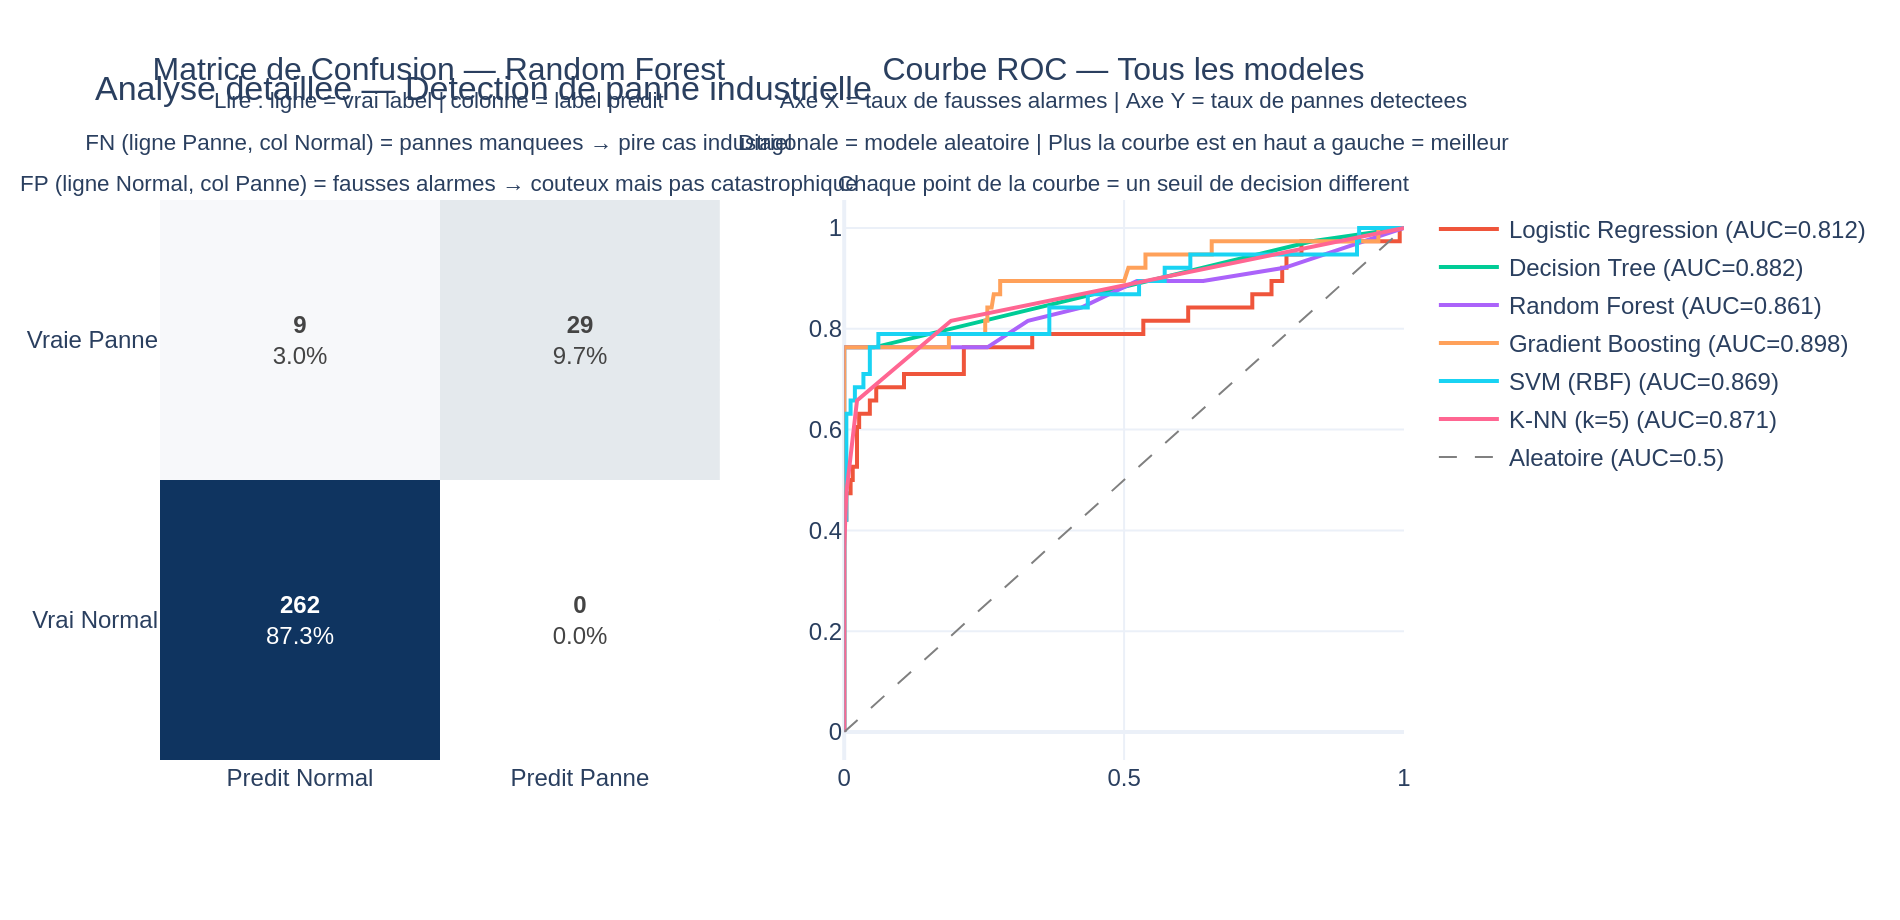

Resultats Random Forest : TP=29 | FP=0 | FN=9 | TN=262
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98       262
       Panne       1.00      0.76      0.87        38

    accuracy                           0.97       300
   macro avg       0.98      0.88      0.92       300
weighted avg       0.97      0.97      0.97       300



In [10]:
rf_pipe   = clf_results["Random Forest"]["pipe"]
y_pred_rf = clf_results["Random Forest"]["yp"]
y_prob_rf = clf_results["Random Forest"]["yprob"]
cm = confusion_matrix(y_te_m, y_pred_rf)
tn,fp,fn,tp = cm.ravel()

fig = make_subplots(rows=1,cols=2,
    subplot_titles=(
        "Matrice de Confusion — Random Forest<br>"
        "<sup>Lire : ligne = vrai label | colonne = label predit<br>"
        "FN (ligne Panne, col Normal) = pannes manquees → pire cas industriel<br>"
        "FP (ligne Normal, col Panne) = fausses alarmes → couteux mais pas catastrophique</sup>",
        "Courbe ROC — Tous les modeles<br>"
        "<sup>Axe X = taux de fausses alarmes | Axe Y = taux de pannes detectees<br>"
        "Diagonale = modele aleatoire | Plus la courbe est en haut a gauche = meilleur<br>"
        "Chaque point de la courbe = un seuil de decision different</sup>"
    ))

annot = [[f"<b>{cm[i,j]}</b><br>{cm[i,j]/cm.sum()*100:.1f}%" for j in range(2)] for i in range(2)]
fig.add_trace(go.Heatmap(z=cm,x=["Predit Normal","Predit Panne"],
    y=["Vrai Normal","Vraie Panne"],colorscale=[[0,"white"],[1,COLORS["secondary"]]],
    text=annot,texttemplate="%{text}",showscale=False),row=1,col=1)

for name,r in clf_results.items():
    if r["yprob"] is not None:
        fig.add_trace(go.Scatter(x=r["fpr"],y=r["tpr"],mode="lines",
            name=f"{name} (AUC={r['auc']:.3f})",line=dict(width=2)),row=1,col=2)
fig.add_trace(go.Scatter(x=[0,1],y=[0,1],mode="lines",
    line=dict(dash="dash",color="gray",width=1),name="Aleatoire (AUC=0.5)"),row=1,col=2)
fig.update_layout(height=460,template="plotly_white",
    title="Analyse detaillee — Detection de panne industrielle")
fig.show()

print(f"Resultats Random Forest : TP={tp} | FP={fp} | FN={fn} | TN={tn}")
print(classification_report(y_te_m,y_pred_rf,target_names=["Normal","Panne"]))

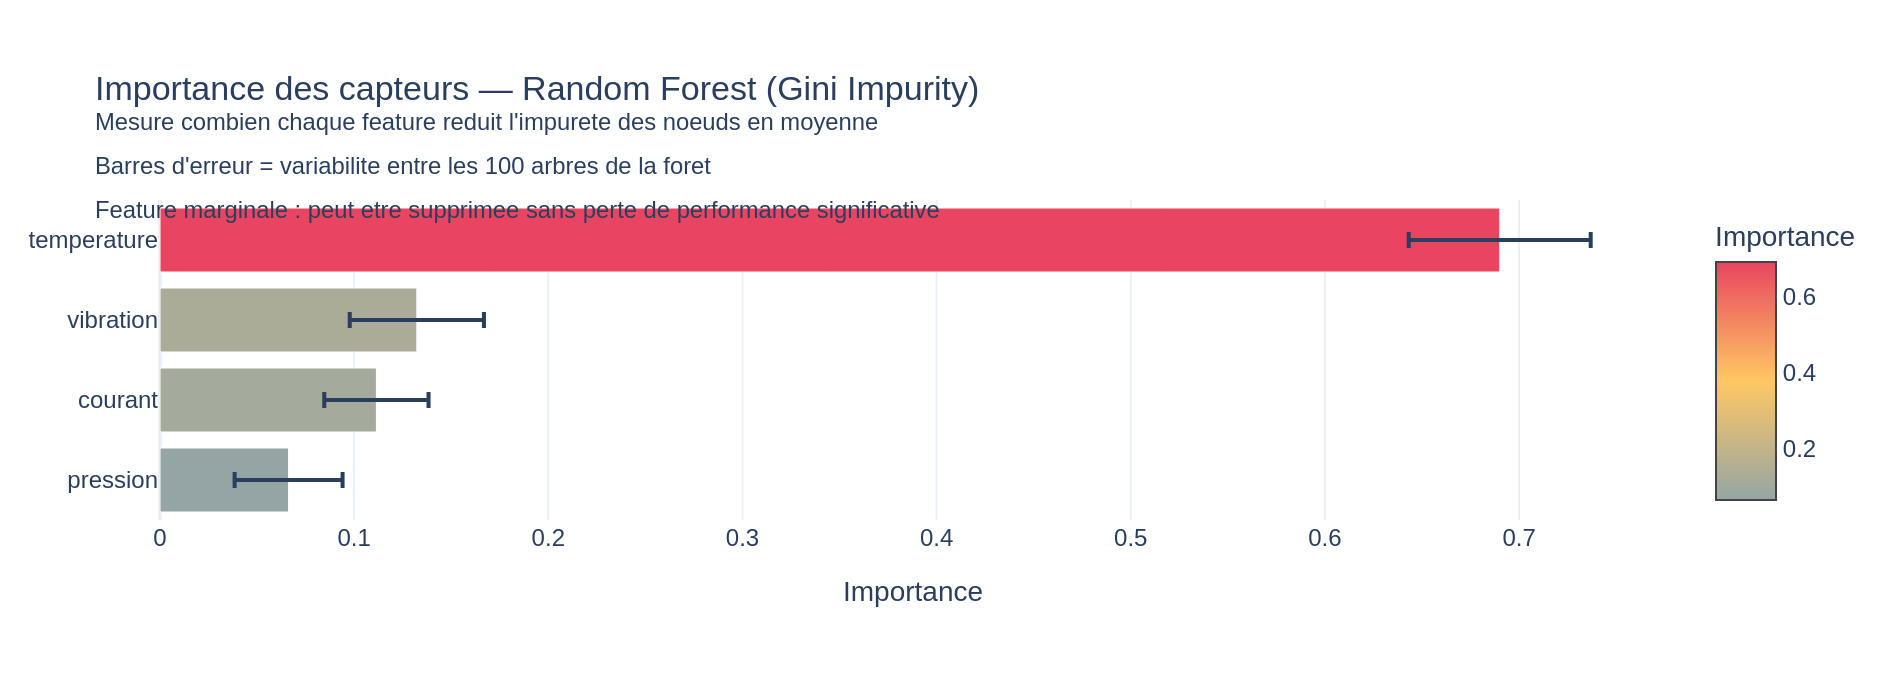

Interpretation metier :
  CRITIQUE   temperature    : 0.690
  Marginal   vibration      : 0.132
  Marginal   courant        : 0.111
  Marginal   pression       : 0.066


In [11]:
rf_model = rf_pipe.named_steps["clf"]
importances = pd.Series(rf_model.feature_importances_, index=X_m.columns)
std_imp = np.std([t.feature_importances_ for t in rf_model.estimators_], axis=0)
std_s   = pd.Series(std_imp, index=X_m.columns).reindex(importances.sort_values().index)
imp_s   = importances.sort_values(ascending=True)

fig = go.Figure(go.Bar(x=imp_s.values, y=imp_s.index, orientation="h",
    error_x=dict(type="data", array=std_s.values, visible=True),
    marker=dict(color=imp_s.values,
                colorscale=[[0,COLORS["neutral"]],[0.5,COLORS["accent"]],[1,COLORS["primary"]]],
                showscale=True,colorbar=dict(title="Importance")),
    hovertemplate="<b>%{y}</b><br>Importance: %{x:.4f}"))
fig.update_layout(
    title="Importance des capteurs — Random Forest (Gini Impurity)<br>"
          "<sup>Mesure combien chaque feature reduit l'impurete des noeuds en moyenne<br>"
          "Barres d'erreur = variabilite entre les 100 arbres de la foret<br>"
          "Feature marginale : peut etre supprimee sans perte de performance significative</sup>",
    xaxis_title="Importance",height=340,template="plotly_white")
fig.show()
print("Interpretation metier :")
for f,i in importances.sort_values(ascending=False).items():
    tag = "CRITIQUE" if i>0.30 else ("Important" if i>0.15 else "Marginal")
    print(f"  {tag:<10} {f:<15}: {i:.3f}")

---
<div style="background:linear-gradient(90deg,#ffc864,#f39c12);padding:18px 24px;border-radius:10px;color:#1a1a2e;margin:20px 0;">
<h1 style="margin:0;">🔵 Partie 4 — Clustering : Grouper sans Labels</h1>
</div>

## 4.1 — Qu'est-ce que le clustering ?

Le clustering est un apprentissage **non supervisé** : on n'a pas de labels, on cherche des **groupes naturels** dans les données.

> **Analogie :** Imaginez un entrepôt avec 10 000 produits mélangés. Sans étiquettes, vous remarquez naturellement que certains produits se ressemblent — vous les regroupez. C'est exactement ce que fait le clustering.

### Exemples industriels
- **Segmentation clients :** regrouper les clients par comportement d'achat pour personnaliser les offres
- **Maintenance :** regrouper les pannes par similitude pour identifier les types de défauts
- **Génomique :** regrouper des gènes à expression similaire
- **Anomalie :** tout point qui n'appartient à aucun groupe est suspect

---

## 4.2 — K-Means : l'algorithme le plus populaire

### L'algorithme en 4 étapes

1. **Initialisation :** placer K centroïdes aléatoirement dans l'espace
2. **Attribution :** assigner chaque point au centroïde le plus proche
3. **Mise à jour :** déplacer chaque centroïde vers le centre de son groupe
4. **Répéter** les étapes 2-3 jusqu'à convergence (plus de changement)

> **Analogie :** K personnes se placent dans une salle bondée. Chaque personne dans la salle va vers la personne de référence la plus proche. Chaque référence se déplace vers le centre de son groupe. On répète jusqu'à stabilisation.

### Choisir le bon nombre de clusters K

C'est le principal défi du K-Means. Trois méthodes complémentaires :

**Méthode du coude (Elbow Method)**
On trace l'inertie (somme des distances² aux centroïdes) en fonction de K. On cherche le "coude" où la courbe s'aplatit — ajouter plus de clusters n'apporte plus grand chose.

**Score de Silhouette**
Mesure pour chaque point : est-il plus proche des membres de son propre cluster (cohésion) que des membres des autres clusters (séparation) ?
- Score proche de +1 : bien classifié
- Score proche de 0 : sur la frontière
- Score négatif : probablement mal assigné

**Score de Davies-Bouldin**
Mesure la similarité moyenne entre chaque cluster et son cluster le plus similaire. Plus c'est bas, mieux c'est.

---

## 4.3 — DBSCAN : clusters de forme arbitraire

K-Means a une limitation : il suppose des clusters **sphériques**. DBSCAN (Density-Based Spatial Clustering) peut trouver des clusters de **n'importe quelle forme**.

### L'idée intuitive
DBSCAN définit un cluster comme une **zone dense** de points. Il distingue :
- **Points noyaux :** ont suffisamment de voisins proches
- **Points frontière :** proches d'un noyau mais pas assez denses eux-mêmes
- **Points bruit (outliers) :** isolés, n'appartiennent à aucun cluster

**Avantage majeur :** détecte automatiquement les outliers (points bruit) → utile pour la détection d'anomalies.

---

## 4.4 — Clustering Hiérarchique

Construit une **hiérarchie de clusters** (dendrogramme) sans avoir à fixer K à l'avance.

**Approche agglomérative (bottom-up) :**
1. Départ : chaque point est son propre cluster
2. Fusionner les deux clusters les plus proches
3. Répéter jusqu'à n'avoir plus qu'un seul cluster
4. Couper l'arbre à la hauteur souhaitée pour obtenir K clusters

**Avantage :** visualisation intuitive avec le dendrogramme, pas besoin de fixer K a priori.


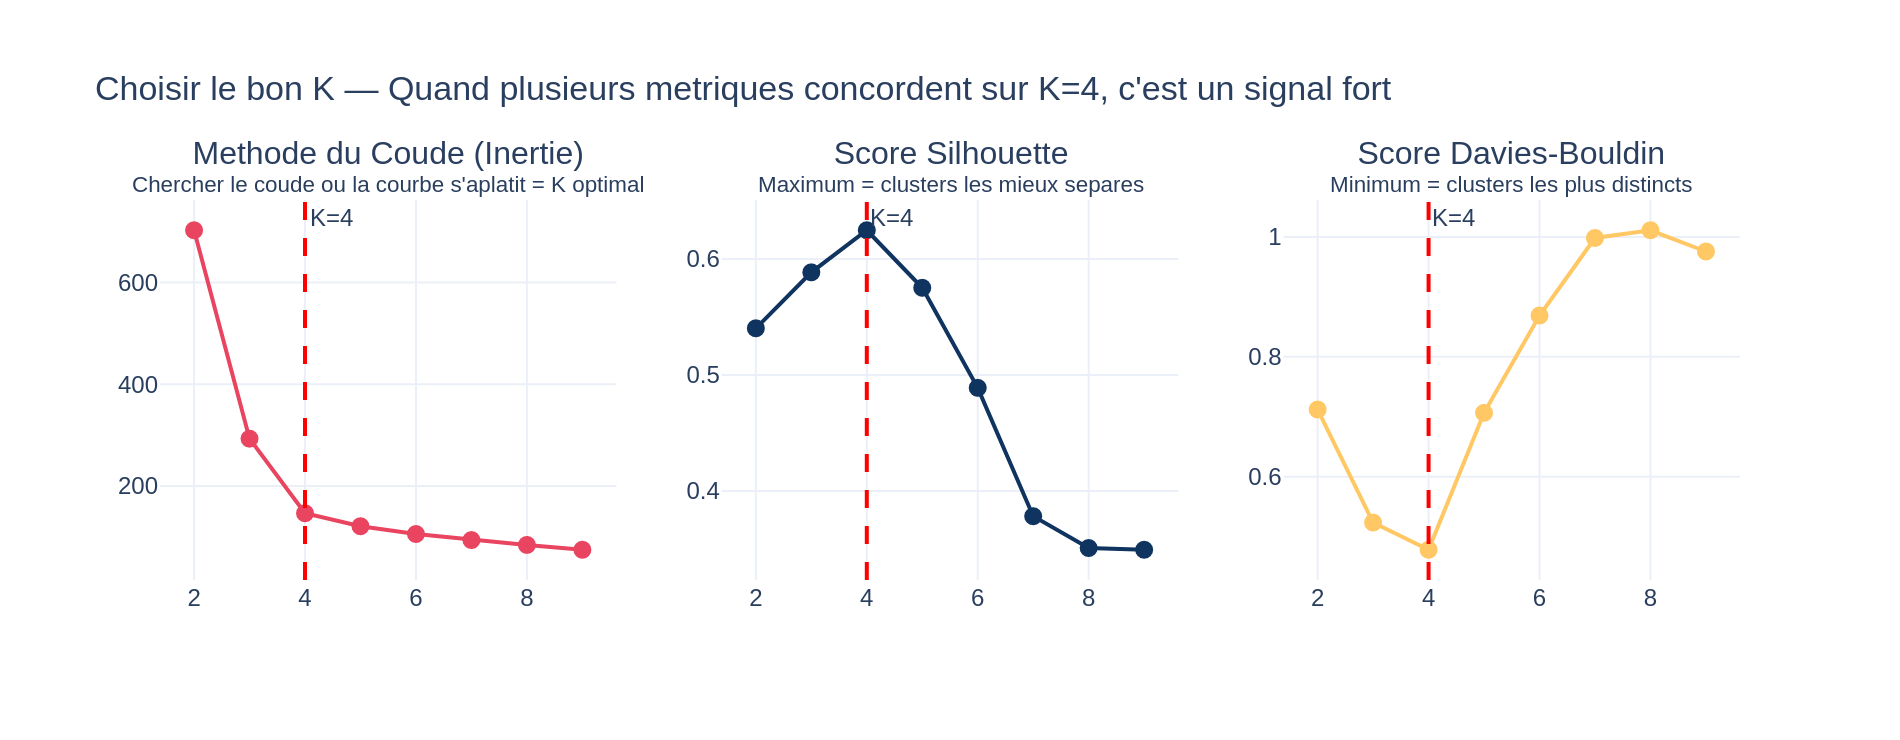

In [12]:
np.random.seed(0)
segs = {
    "Champions":    {"n":120,"rfm":[5, 10,2000],"std":[1,  2,  300]},
    "Reguliers":    {"n":200,"rfm":[20, 5, 800],"std":[5,  1,  150]},
    "Occasionnels": {"n":180,"rfm":[60, 2, 300],"std":[15, 1,   80]},
    "Inactifs":     {"n":100,"rfm":[120,1, 100],"std":[20, 0.3, 30]},
}
frames = []
for seg,p in segs.items():
    frames.append(pd.DataFrame({
        "recence":   np.abs(np.random.normal(p["rfm"][0],p["std"][0],p["n"])),
        "frequence": np.abs(np.random.normal(p["rfm"][1],p["std"][1],p["n"])),
        "montant":   np.abs(np.random.normal(p["rfm"][2],p["std"][2],p["n"])),
        "vrai_seg":  seg,
    }))
clients = pd.concat(frames,ignore_index=True).sample(frac=1,random_state=42)
X_cl    = clients[["recence","frequence","montant"]]
Xs_cl   = StandardScaler().fit_transform(X_cl)

K_range = range(2,10)
inertias,silhs,dbs = [],[],[]
for k in K_range:
    km  = KMeans(n_clusters=k,random_state=42,n_init=10)
    lbl = km.fit_predict(Xs_cl)
    inertias.append(km.inertia_)
    silhs.append(silhouette_score(Xs_cl,lbl))
    dbs.append(davies_bouldin_score(Xs_cl,lbl))

kvals = list(K_range)
fig = make_subplots(rows=1,cols=3,
    subplot_titles=(
        "Methode du Coude (Inertie)<br><sup>Chercher le coude ou la courbe s'aplatit = K optimal</sup>",
        "Score Silhouette<br><sup>Maximum = clusters les mieux separes</sup>",
        "Score Davies-Bouldin<br><sup>Minimum = clusters les plus distincts</sup>"
    ))
for i,(vals,col) in enumerate([(inertias,1),(silhs,2),(dbs,3)]):
    fig.add_trace(go.Scatter(x=kvals,y=vals,mode="lines+markers",
        line=dict(color=PALETTE[i],width=2),marker=dict(size=9)),row=1,col=col)
    fig.add_vline(x=4,line_dash="dash",line_color="red",
                  annotation_text="K=4",row=1,col=col)
fig.update_layout(height=370,template="plotly_white",showlegend=False,
    title="Choisir le bon K — Quand plusieurs metriques concordent sur K=4, c'est un signal fort")
fig.show()

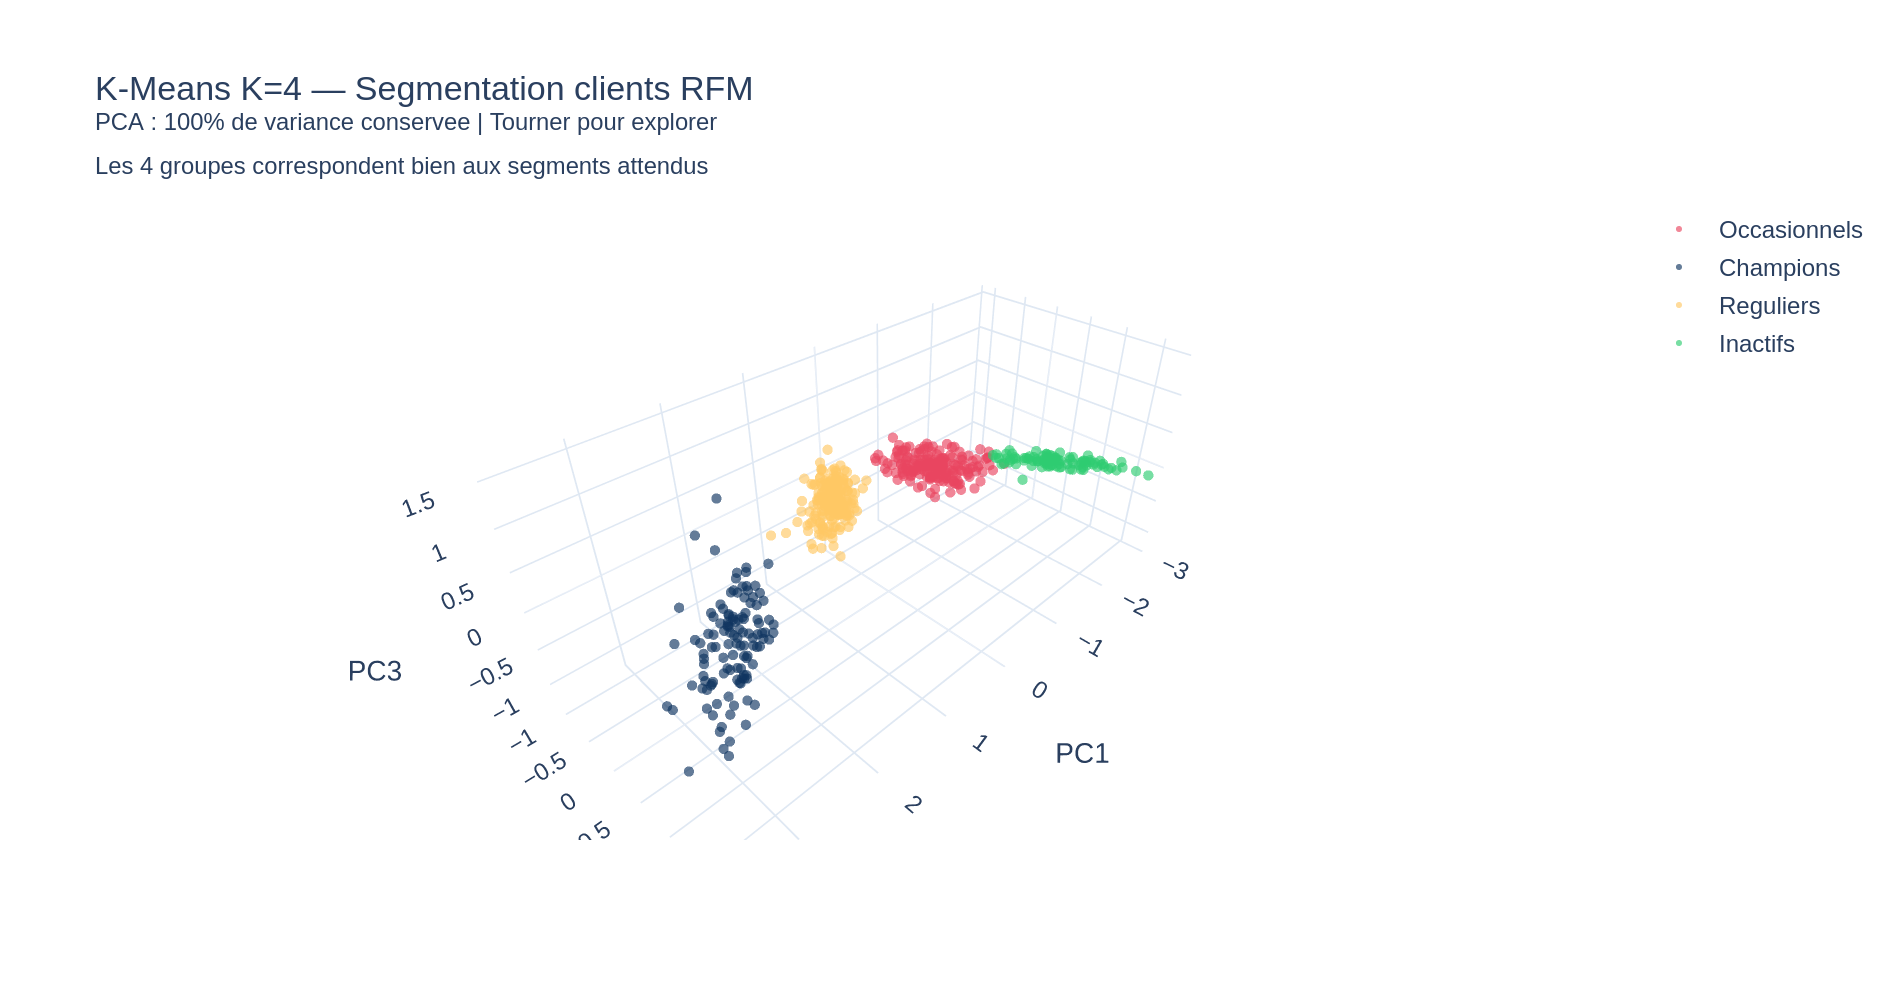

Profil des 4 segments :
         Taille  Recence  Frequence  Montant       Segment
cluster                                                   
0           185     61.8        2.0    295.0  Occasionnels
1           119      5.1        9.9   1961.4     Champions
2           201     19.5        4.9    801.9     Reguliers
3            95    123.4        1.0    100.4      Inactifs


In [13]:
km4  = KMeans(n_clusters=4,random_state=42,n_init=10)
lbl4 = km4.fit_predict(Xs_cl)
clients["cluster"] = lbl4

pca3c = PCA(n_components=3)
X3cl  = pca3c.fit_transform(Xs_cl)
vexp  = pca3c.explained_variance_ratio_

cnames = {}
for c in range(4):
    m  = lbl4==c
    fr = X_cl.loc[m,"frequence"].mean()
    mo = X_cl.loc[m,"montant"].mean()
    re = X_cl.loc[m,"recence"].mean()
    if   fr>7  and mo>1200: cnames[c]="Champions"
    elif re>90:             cnames[c]="Inactifs"
    elif fr>4:              cnames[c]="Reguliers"
    else:                   cnames[c]="Occasionnels"

fig = go.Figure()
for c in range(4):
    m = lbl4==c
    fig.add_trace(go.Scatter3d(x=X3cl[m,0],y=X3cl[m,1],z=X3cl[m,2],
        mode="markers",name=cnames[c],marker=dict(size=3,color=PALETTE[c],opacity=0.65)))
fig.update_layout(
    title=(f"K-Means K=4 — Segmentation clients RFM<br>"
           f"<sup>PCA : {vexp.sum()*100:.0f}% de variance conservee | Tourner pour explorer<br>"
           "Les 4 groupes correspondent bien aux segments attendus</sup>"),
    scene=dict(xaxis_title="PC1",yaxis_title="PC2",zaxis_title="PC3"),
    height=500,template="plotly_white")
fig.show()

profil = clients.groupby("cluster").agg(
    Taille=("cluster","count"),
    Recence=("recence","mean"),
    Frequence=("frequence","mean"),
    Montant=("montant","mean")
).round(1)
profil["Segment"] = profil.index.map(cnames)
print("Profil des 4 segments :")
print(profil.to_string())

---
<div style="background:linear-gradient(90deg,#9b59b6,#8e44ad);padding:18px 24px;border-radius:10px;color:white;margin:20px 0;">
<h1 style="margin:0;">🔍 Partie 5 — Reduction de Dimension : PCA</h1>
</div>

## PCA — Analyse en Composantes Principales

### Pourquoi reduire la dimension ?

Avec des datasets a des dizaines ou centaines de variables, la visualisation devient impossible et certains algorithmes souffrent de la "malediction de la dimensionnalite".

### L'idee intuitive

PCA cherche les **axes qui capturent le maximum de variance** dans les donnees.

La premiere composante (PC1) = direction de plus grande variance.
La deuxieme (PC2) = perpendiculaire a PC1, capture la variance residuelle maximum.

> **Analogie :** Photographier un objet 3D. La photo (2D) perd une dimension mais capture l'essentiel si on choisit le bon angle. PCA choisit automatiquement le meilleur angle.

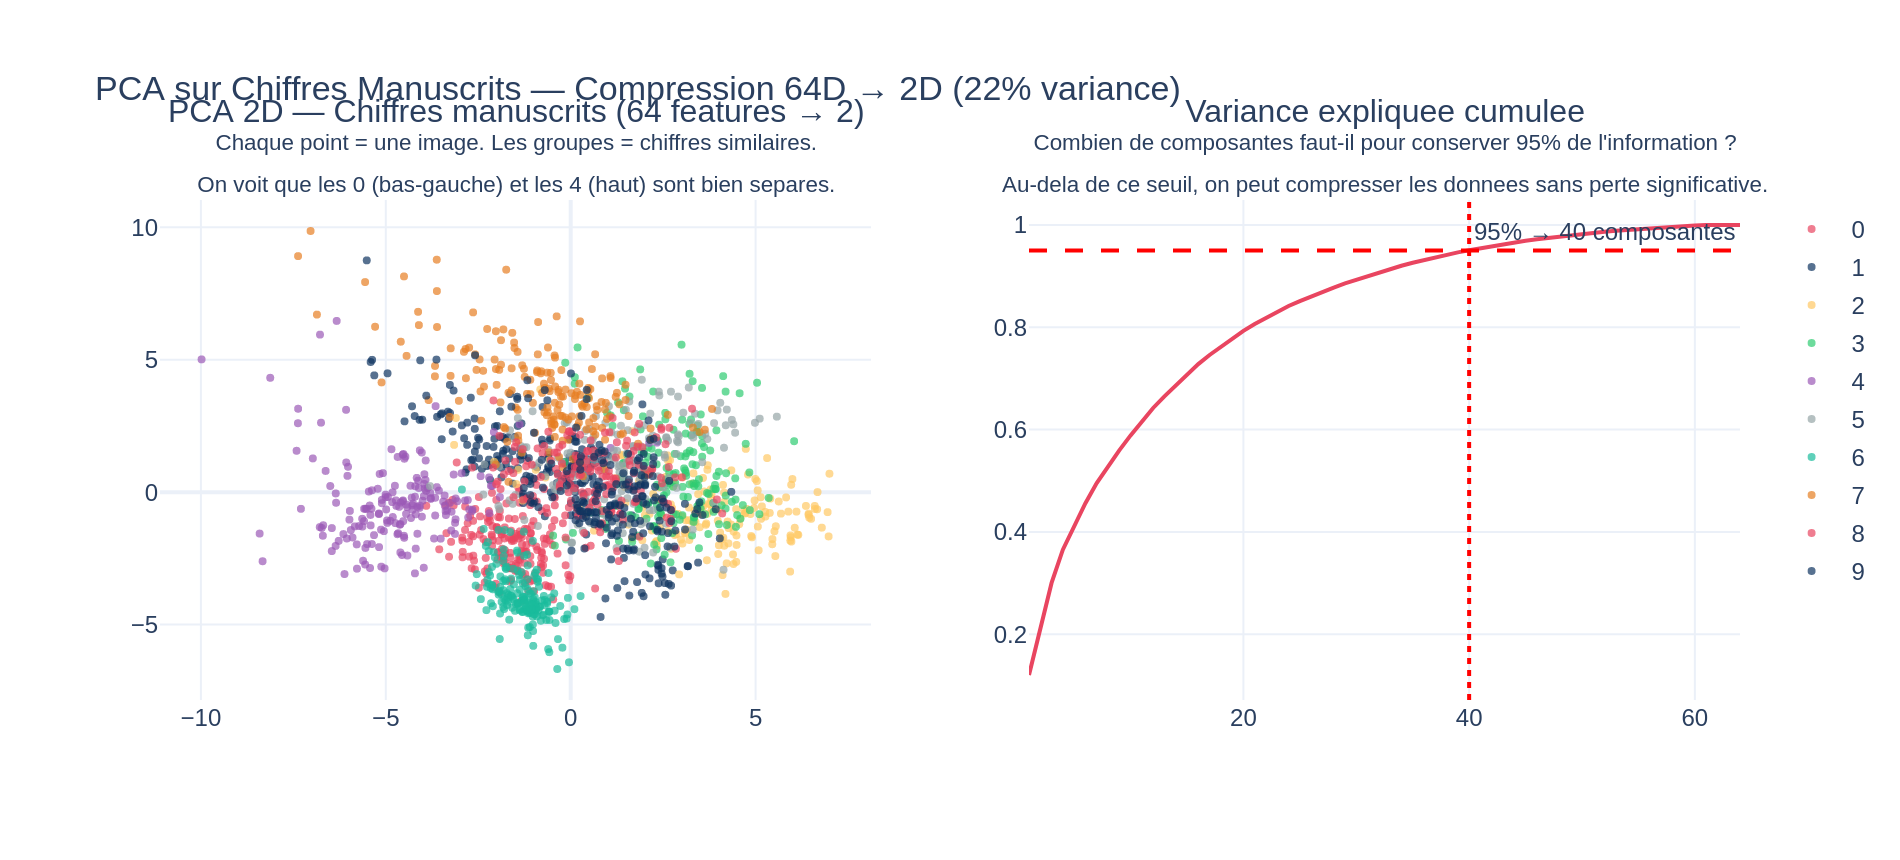

Avec 2 composantes  : 21.6% de variance conservee
Avec 40 composantes : 95% de variance conservee
Compression : 64 → 40 dimensions (62% de la taille originale)


In [14]:
from sklearn.datasets import load_digits

digits = load_digits()
Xd     = digits.data    # 1797 images 8x8 = 64 features
yd     = digits.target  # chiffre 0-9

pca2 = PCA(n_components=2)
Xd2  = pca2.fit_transform(StandardScaler().fit_transform(Xd))
var2 = pca2.explained_variance_ratio_

pca_full = PCA().fit(StandardScaler().fit_transform(Xd))
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n95      = np.argmax(cum_var >= 0.95) + 1

fig = make_subplots(rows=1,cols=2,
    subplot_titles=(
        "PCA 2D — Chiffres manuscrits (64 features → 2)<br>"
        "<sup>Chaque point = une image. Les groupes = chiffres similaires.<br>"
        "On voit que les 0 (bas-gauche) et les 4 (haut) sont bien separes.</sup>",
        "Variance expliquee cumulee<br>"
        "<sup>Combien de composantes faut-il pour conserver 95% de l'information ?<br>"
        "Au-dela de ce seuil, on peut compresser les donnees sans perte significative.</sup>"
    ))

for digit in range(10):
    m = yd==digit
    fig.add_trace(go.Scatter(x=Xd2[m,0],y=Xd2[m,1],mode="markers",name=str(digit),
        marker=dict(size=4,color=PALETTE[digit%len(PALETTE)],opacity=0.7)),row=1,col=1)

fig.add_trace(go.Scatter(x=list(range(1,len(cum_var)+1)),y=cum_var,mode="lines",
    line=dict(color=COLORS["primary"],width=2),showlegend=False),row=1,col=2)
fig.add_hline(y=0.95,line_dash="dash",line_color="red",
    annotation_text=f"95% → {n95} composantes",row=1,col=2)
fig.add_vline(x=n95,line_dash="dot",line_color="red",row=1,col=2)

fig.update_layout(height=430,template="plotly_white",
    title=f"PCA sur Chiffres Manuscrits — Compression 64D → 2D ({var2.sum()*100:.0f}% variance)")
fig.show()
print(f"Avec 2 composantes  : {var2.sum()*100:.1f}% de variance conservee")
print(f"Avec {n95} composantes : 95% de variance conservee")
print(f"Compression : 64 → {n95} dimensions ({n95/64*100:.0f}% de la taille originale)")

---
<div style="background:linear-gradient(90deg,#e74c3c,#c0392b);padding:18px 24px;border-radius:10px;color:white;margin:20px 0;">
<h1 style="margin:0;">⚠️ Partie 6 — Detection d'Anomalies</h1>
</div>

## Isolation Forest

### L'idee intuitive

Un point **normal** est entoure de voisins — il faut beaucoup de coupures aleatoires pour l'isoler.

Un point **anormal** est seul dans l'espace — quelques coupures suffisent.

> **Analogie :** Isoler un mouton noir dans un troupeau blanc = une clotûre suffit. Isoler un mouton blanc = il faut beaucoup de clotûres.

**Avantages :** rapide, pas besoin de labels, gere bien la haute dimension.
**Parametre cle :** `contamination` = proportion estimee d'anomalies (a regler selon la connaissance metier).

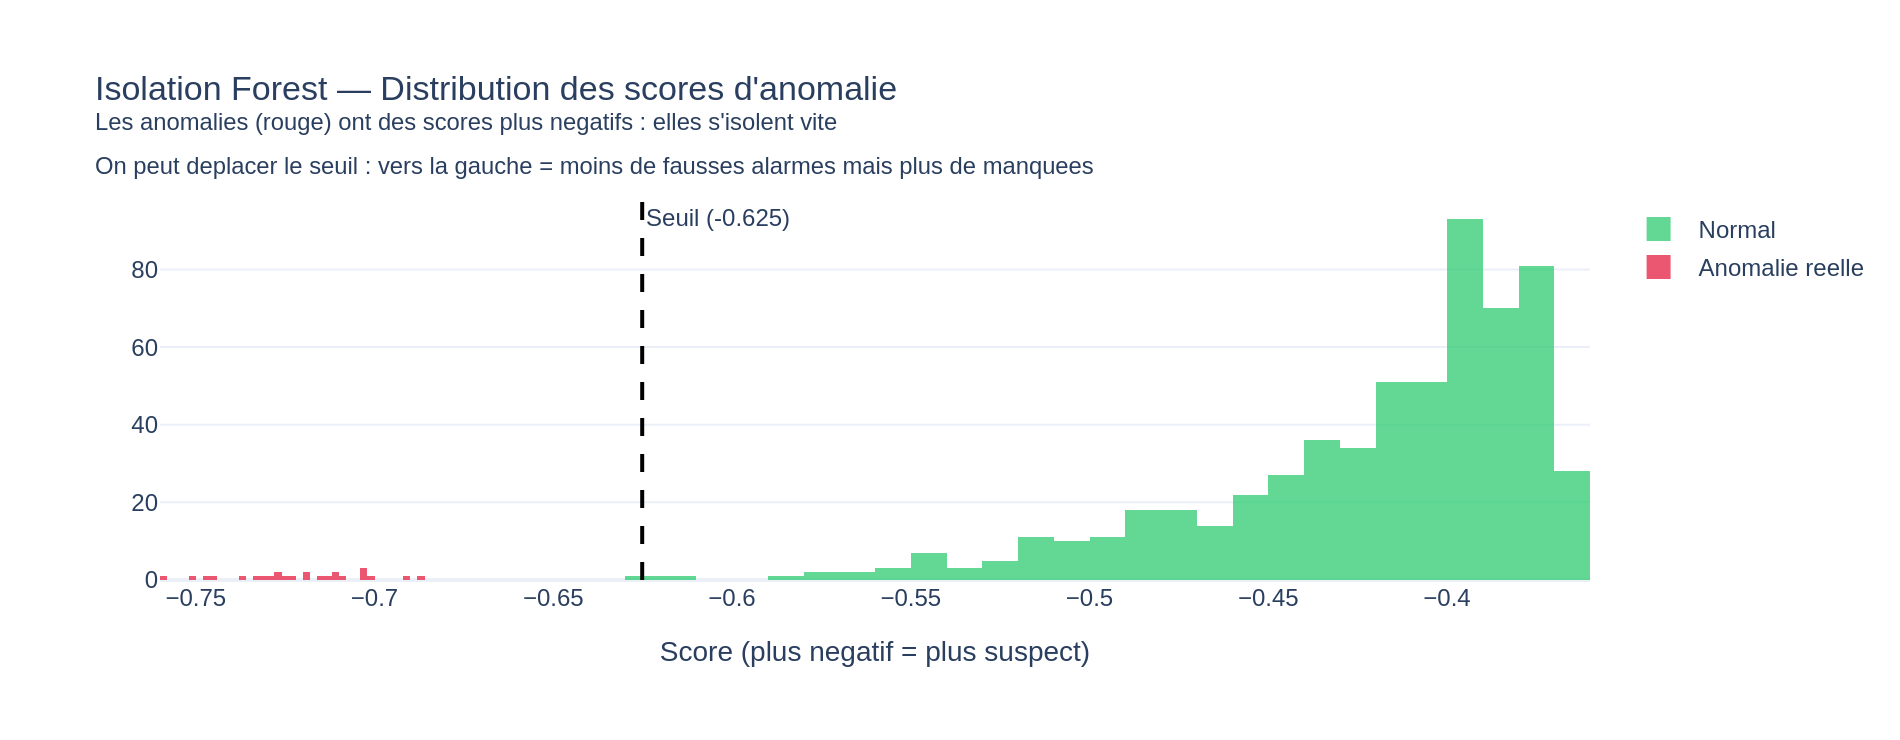

Anomalies detectees (Rappel)  : 25/25 = 100%
Fausses alarmes               : 0/25 = 0%


In [15]:
np.random.seed(42)
n_norm,n_anom = 600,25
X_norm = np.column_stack([np.random.normal(100,15,n_norm),
                           np.random.normal(5,1,n_norm),
                           np.random.normal(1000,200,n_norm)])
X_anom = np.column_stack([np.random.normal(500,50,n_anom),
                           np.random.normal(50,10,n_anom),
                           np.random.normal(50000,5000,n_anom)])
X_res  = np.vstack([X_norm,X_anom])
y_real = np.array([1]*n_norm+[-1]*n_anom)
X_sc   = StandardScaler().fit_transform(X_res)
iso    = IsolationForest(contamination=0.04,random_state=42)
iso_lbl= iso.fit_predict(X_sc)
iso_scr= iso.score_samples(X_sc)

fig = go.Figure()
fig.add_trace(go.Histogram(x=iso_scr[y_real==1],name="Normal",
    opacity=0.75,marker_color=COLORS["success"],nbinsx=50))
fig.add_trace(go.Histogram(x=iso_scr[y_real==-1],name="Anomalie reelle",
    opacity=0.9,marker_color=COLORS["primary"],nbinsx=50))
fig.add_vline(x=iso.offset_,line_dash="dash",line_color="black",
    annotation_text=f"Seuil ({iso.offset_:.3f})")
fig.update_layout(barmode="overlay",
    title="Isolation Forest — Distribution des scores d'anomalie<br>"
          "<sup>Les anomalies (rouge) ont des scores plus negatifs : elles s'isolent vite<br>"
          "On peut deplacer le seuil : vers la gauche = moins de fausses alarmes mais plus de manquees</sup>",
    xaxis_title="Score (plus negatif = plus suspect)",height=370,template="plotly_white")
fig.show()
tp=((iso_lbl==-1)&(y_real==-1)).sum();fp=((iso_lbl==-1)&(y_real==1)).sum()
fn=((iso_lbl==1)&(y_real==-1)).sum()
print(f"Anomalies detectees (Rappel)  : {tp}/{tp+fn} = {tp/(tp+fn):.0%}")
print(f"Fausses alarmes               : {fp}/{tp+fp} = {fp/(tp+fp):.0%}")

---
<div style="background:linear-gradient(90deg,#1abc9c,#16a085);padding:18px 24px;border-radius:10px;color:white;margin:20px 0;">
<h1 style="margin:0;">💬 Partie 7 — NLP : Traitement du Langage Naturel</h1>
</div>

## TF-IDF : transformer du texte en nombres

Les algorithmes ML ont besoin de nombres. TF-IDF est la transformation standard.

**TF (Term Frequency)** = frequence d'un mot dans un document.

**IDF (Inverse Document Frequency)** = logarithme de (nb total documents / nb documents contenant ce mot).
→ Un mot tres rare dans le corpus est plus informatif qu'un mot commun comme "le" ou "de".

**TF-IDF** = TF x IDF = haut si le mot est frequent dans CE document mais rare dans les AUTRES.

**N-grammes :** Les bigrammes (2 mots consecutifs) capturent des expressions composees.
→ "pas bien" (bigramme) est different de "pas" seul et "bien" seul.

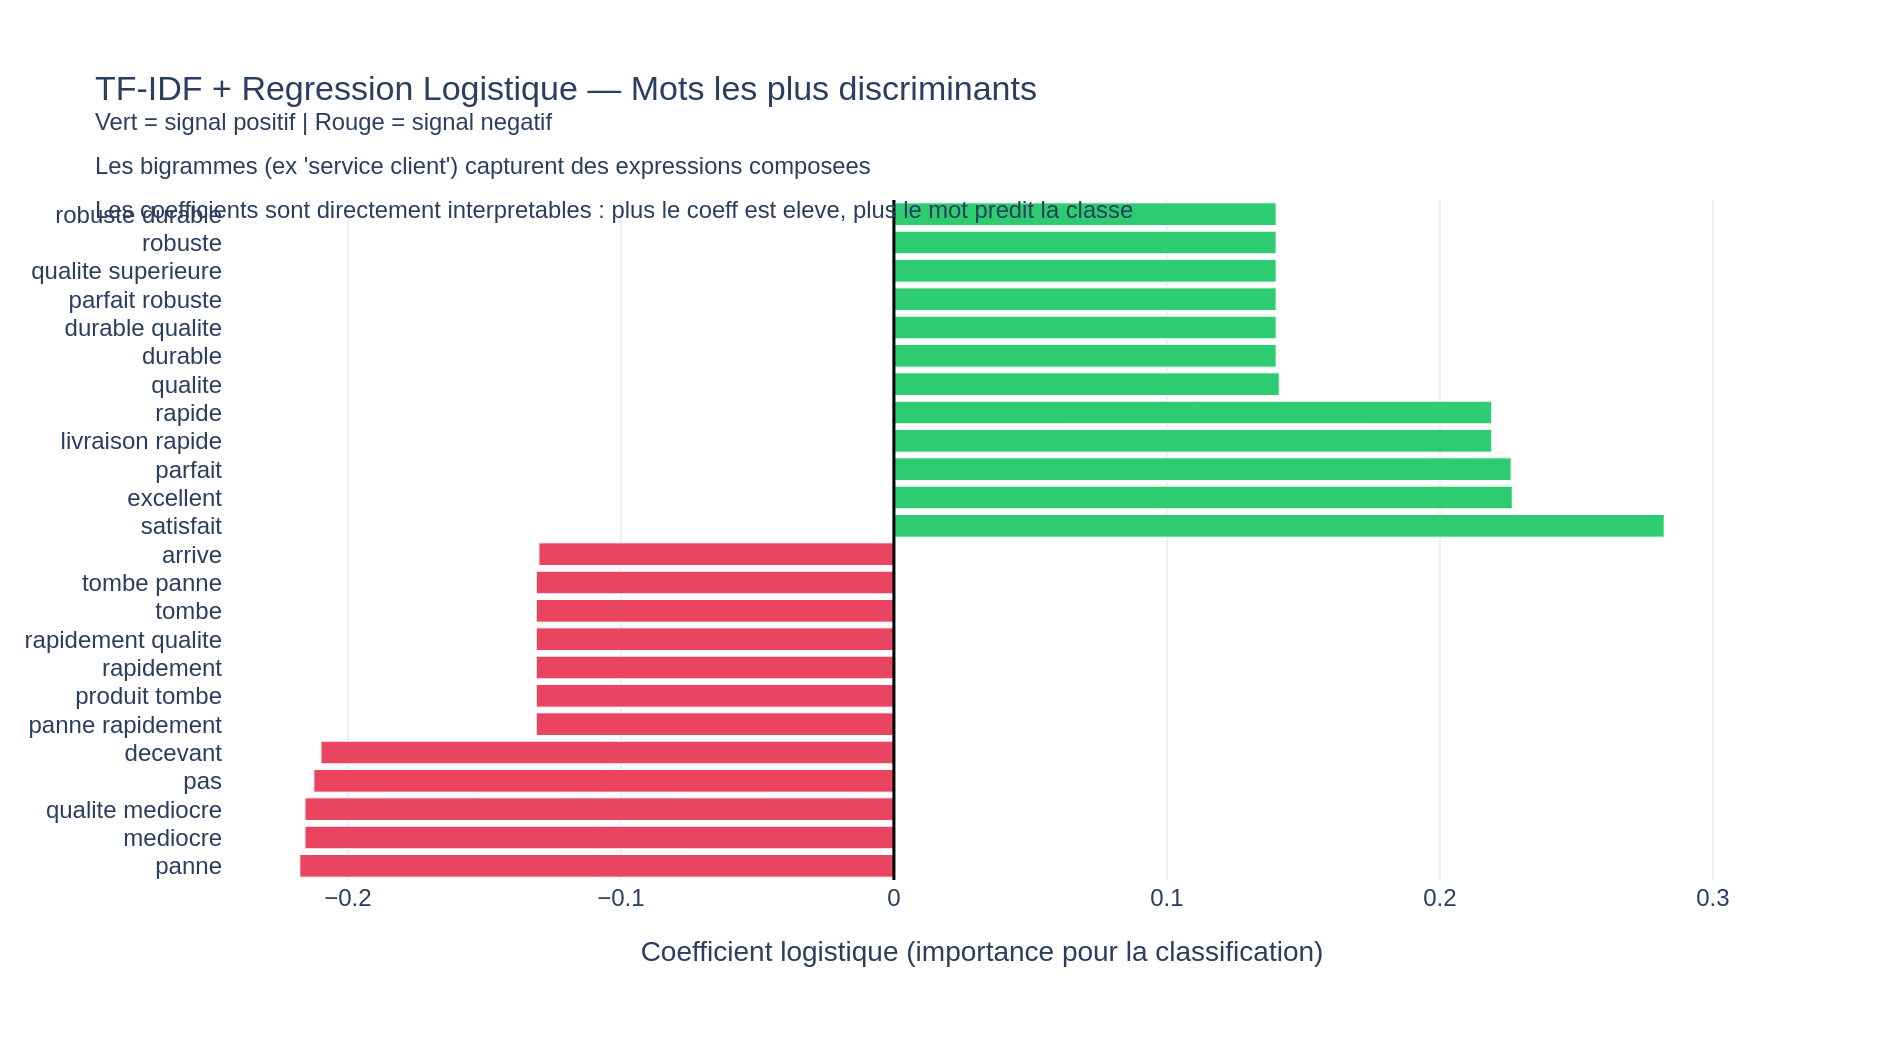

Test sur nouveaux avis :
  NEGATIF (48%) : Produit arrive casse impossible rembourser service nul
  POSITIF (54%) : Excellente qualite tres content achat rapide
  POSITIF (51%) : Produit correct mais livraison decevante et lente


In [16]:
feedbacks = [
    "Excellent produit livraison rapide qualite irrepprochable",
    "Tres satisfait qualite service apres-vente parfait",
    "Produit conforme description installation facile recommande",
    "Parfait robuste durable qualite superieure",
    "Bon rapport qualite prix livraison rapide satisfait",
    "Super qualite bien emballe service impeccable",
    "Produit solide fiable usage intensif excellent",
    "Service client reactif produit comme decrit satisfait",
    "Panne bout 3 jours service client inexistant decevant",
    "Mauvaise qualite produit ne correspond pas description",
    "Livraison retard produit endommage arrive decu",
    "Produit tombe panne rapidement qualite mediocre",
    "Service catastrophique aucune reponse support horrible",
    "Qualite mediocre prix trop eleve deconseille fortement",
    "Produit defaillant premiere utilisation arnaque total",
    "Tres decevant vaut pas investissement evitez",
]
sentiments = [1,1,1,1,1,1,1,1, 0,0,0,0,0,0,0,0]

nlp_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2),min_df=1,max_features=300)),
    ("clf",   LogisticRegression(max_iter=1000,C=1.0))
])
nlp_pipe.fit(feedbacks,sentiments)
feat_names = nlp_pipe.named_steps["tfidf"].get_feature_names_out()
coefs      = nlp_pipe.named_steps["clf"].coef_[0]
top_pos = pd.Series(coefs,index=feat_names).nlargest(12)
top_neg = pd.Series(coefs,index=feat_names).nsmallest(12)
all_f   = list(top_neg.index)+list(top_pos.index)
all_c   = list(top_neg.values)+list(top_pos.values)
col_bc  = [COLORS["primary"] if c<0 else COLORS["success"] for c in all_c]

fig = go.Figure(go.Bar(x=all_c,y=all_f,orientation="h",marker_color=col_bc,
    hovertemplate="Terme: %{y}<br>Coefficient: %{x:.3f}"))
fig.add_vline(x=0,line_color="black",line_width=1.5)
fig.update_layout(height=520,template="plotly_white",
    title="TF-IDF + Regression Logistique — Mots les plus discriminants<br>"
          "<sup>Vert = signal positif | Rouge = signal negatif<br>"
          "Les bigrammes (ex 'service client') capturent des expressions composees<br>"
          "Les coefficients sont directement interpretables : plus le coeff est eleve, plus le mot predit la classe</sup>",
    xaxis_title="Coefficient logistique (importance pour la classification)")
fig.show()
nouveaux = [
    "Produit arrive casse impossible rembourser service nul",
    "Excellente qualite tres content achat rapide",
    "Produit correct mais livraison decevante et lente",
]
probas = nlp_pipe.predict_proba(nouveaux)[:,1]
print("Test sur nouveaux avis :")
for avis,p in zip(nouveaux,probas):
    sentiment = "POSITIF" if p>0.5 else "NEGATIF"
    print(f"  {sentiment} ({p:.0%}) : {avis[:55]}")

---
<div style="background:linear-gradient(90deg,#e67e22,#d35400);padding:18px 24px;border-radius:10px;color:white;margin:20px 0;">
<h1 style="margin:0;">📅 Partie 8 — Series Temporelles</h1>
</div>

## Pourquoi les series temporelles sont differentes ?

L'ordre des donnees compte. On ne peut pas melanger aleatoirement.

**Regle d'or :** Split toujours **temporel** (dernieres donnees = test), jamais aleatoire.

### Feature Engineering temporel

Les algorithmes ML ne voient pas le temps. Il faut creer explicitement des features :

- **Lags :** valeur a t-1, t-4, t-52 (meme semaine l'an passe = capture la saisonnalite annuelle)
- **Rolling :** moyenne et ecart-type sur fenetre glissante (lisse le bruit, detecte les tendances)
- **Calendaire :** semaine de l'annee, trimestre, jour de la semaine

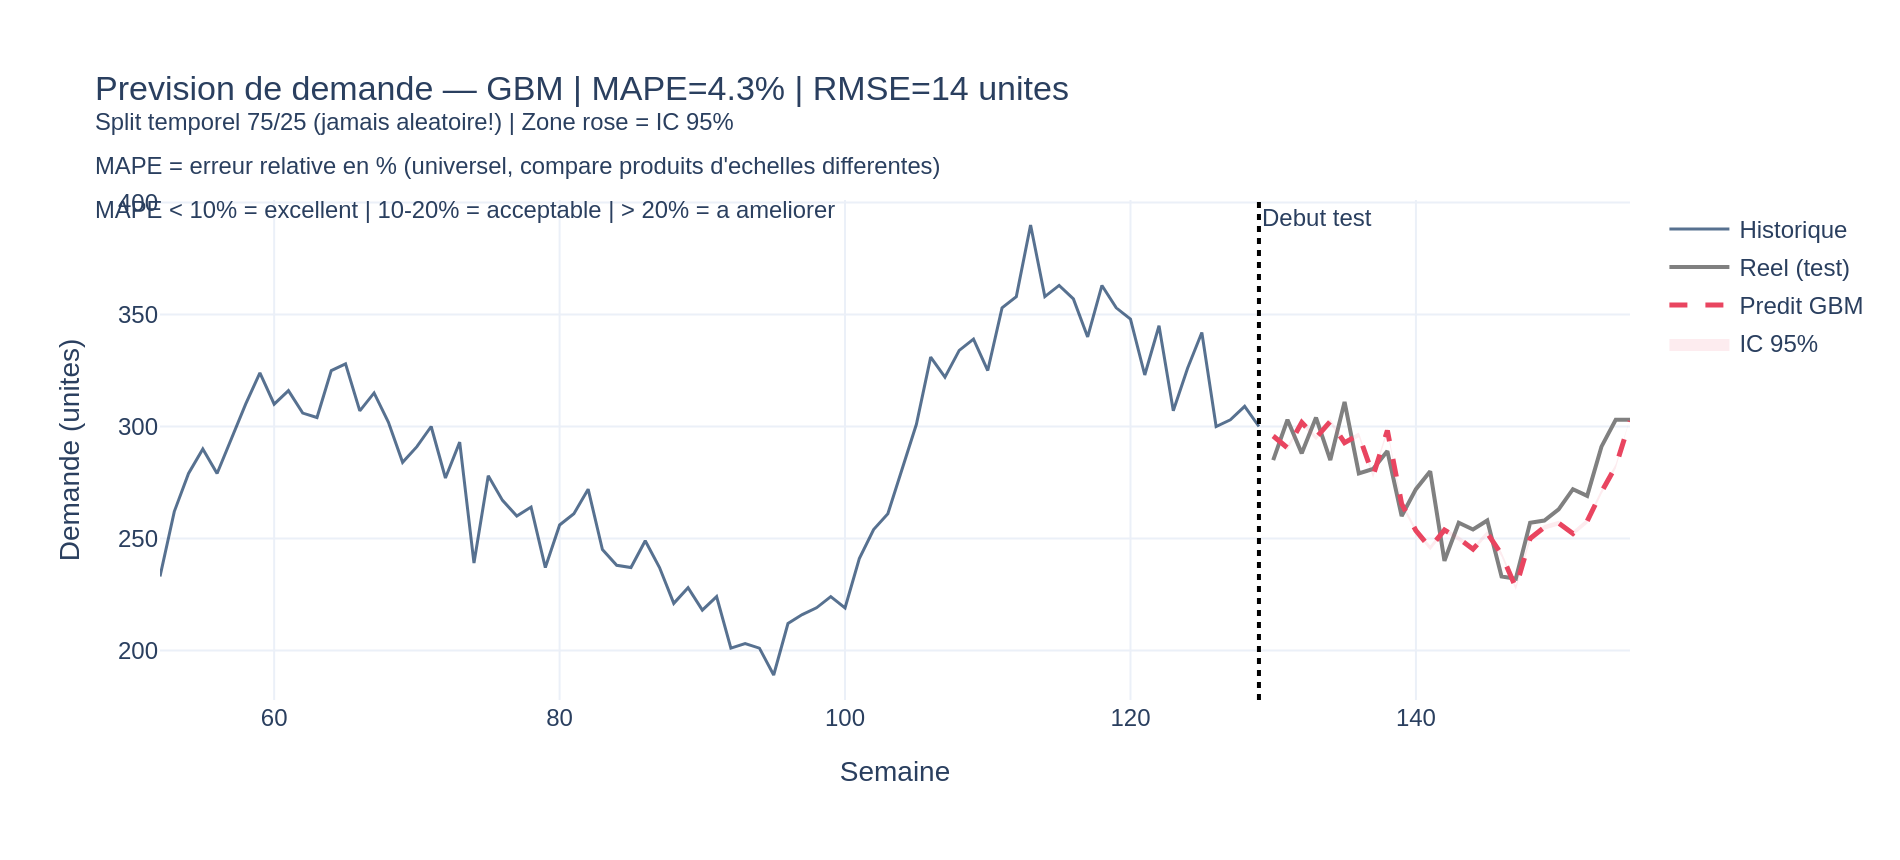

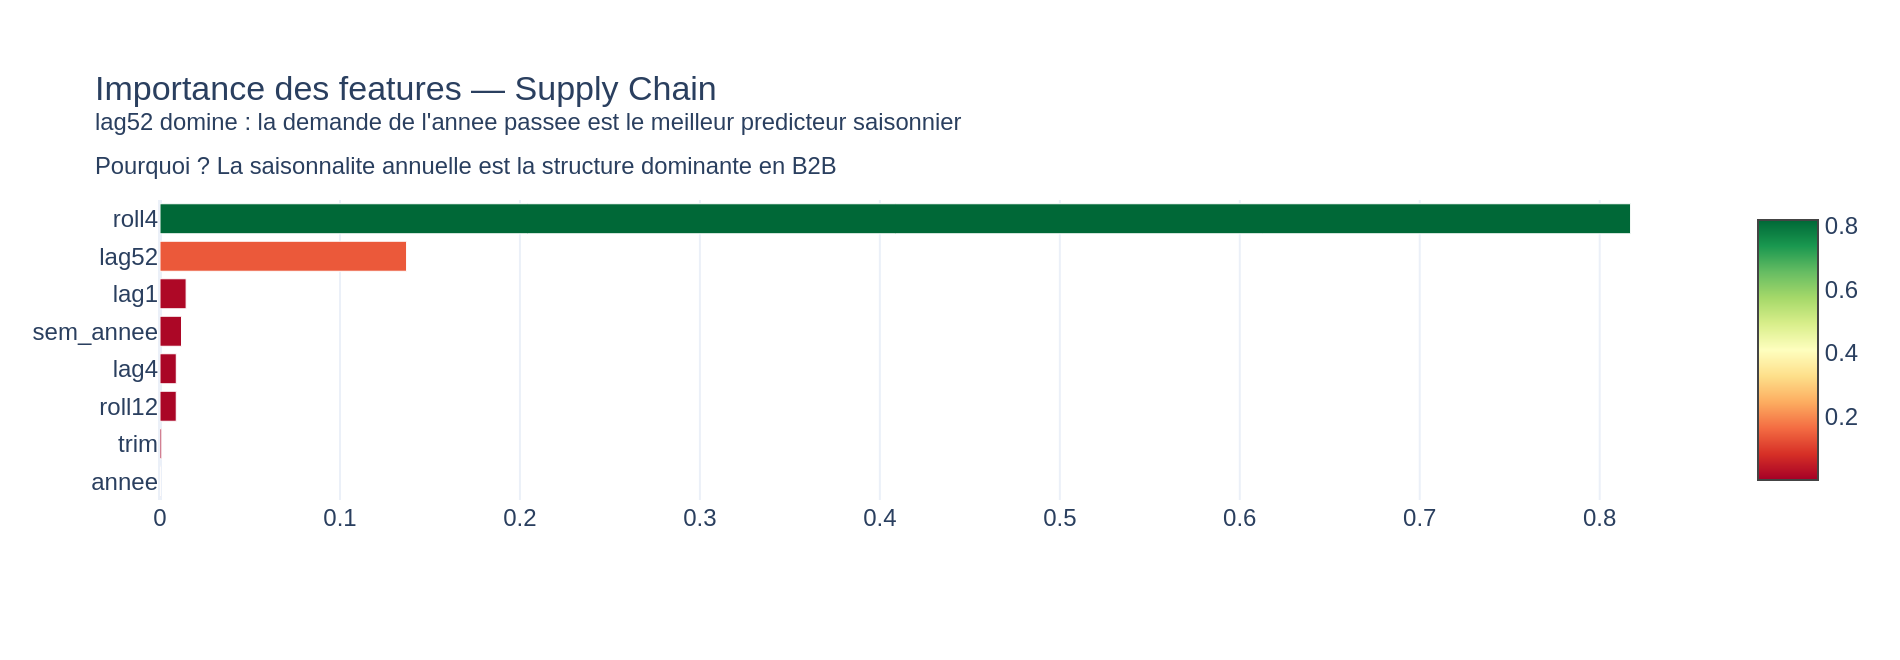

In [17]:
np.random.seed(42)
n_w  = 156
w    = np.arange(n_w)
sais = 60*np.sin(2*np.pi*w/52)+20*np.sin(4*np.pi*w/52)
dem  = np.maximum(200+0.8*w+sais+np.random.normal(0,12,n_w),0).round().astype(float)

df_s = pd.DataFrame({"semaine":w,"demande":dem})
df_s["sem_annee"] = w%52
df_s["annee"]     = w//52
df_s["trim"]      = (w%52)//13
df_s["lag1"]      = df_s["demande"].shift(1)
df_s["lag4"]      = df_s["demande"].shift(4)
df_s["lag52"]     = df_s["demande"].shift(52)
df_s["roll4"]     = df_s["demande"].rolling(4).mean()
df_s["roll12"]    = df_s["demande"].rolling(12).mean()
df_s = df_s.dropna()

split  = int(len(df_s)*0.75)
tr_s,te_s = df_s.iloc[:split],df_s.iloc[split:]
feats  = ["sem_annee","annee","trim","lag1","lag4","lag52","roll4","roll12"]
gbr = GradientBoostingRegressor(n_estimators=200,max_depth=4,learning_rate=0.05,random_state=42)
gbr.fit(tr_s[feats],tr_s["demande"])
yp_s = gbr.predict(te_s[feats])
mape = np.mean(np.abs((te_s["demande"]-yp_s)/te_s["demande"]))*100
rmse_s = np.sqrt(mean_squared_error(te_s["demande"],yp_s))
ci = np.std(tr_s["demande"].values-gbr.predict(tr_s[feats]))*1.96

fig = go.Figure()
fig.add_trace(go.Scatter(x=tr_s["semaine"],y=tr_s["demande"],mode="lines",
    name="Historique",line=dict(color=COLORS["secondary"],width=1.5),opacity=0.7))
fig.add_trace(go.Scatter(x=te_s["semaine"],y=te_s["demande"],mode="lines",
    name="Reel (test)",line=dict(color="gray",width=2)))
fig.add_trace(go.Scatter(x=te_s["semaine"],y=yp_s,mode="lines",
    name=f"Predit GBM",line=dict(color=COLORS["primary"],width=2.5,dash="dash")))
fig.add_trace(go.Scatter(
    x=np.concatenate([te_s["semaine"],te_s["semaine"][::-1]]),
    y=np.concatenate([yp_s+ci,(yp_s-ci)[::-1]]),
    fill="toself",fillcolor="rgba(233,69,96,0.1)",line=dict(width=0),name="IC 95%"))
fig.add_vline(x=tr_s["semaine"].iloc[-1],line_dash="dot",line_color="black",
    annotation_text="Debut test")
fig.update_layout(
    title=(f"Prevision de demande — GBM | MAPE={mape:.1f}% | RMSE={rmse_s:.0f} unites<br>"
           "<sup>Split temporel 75/25 (jamais aleatoire!) | Zone rose = IC 95%<br>"
           "MAPE = erreur relative en % (universel, compare produits d'echelles differentes)<br>"
           "MAPE < 10% = excellent | 10-20% = acceptable | > 20% = a ameliorer</sup>"),
    xaxis_title="Semaine",yaxis_title="Demande (unites)",height=430,template="plotly_white")
fig.show()

fi = pd.Series(gbr.feature_importances_,index=feats).sort_values(ascending=True)
fig2 = go.Figure(go.Bar(x=fi.values,y=fi.index,orientation="h",
    marker=dict(color=fi.values,colorscale="RdYlGn",showscale=True)))
fig2.update_layout(
    title="Importance des features — Supply Chain<br>"
          "<sup>lag52 domine : la demande de l'annee passee est le meilleur predicteur saisonnier<br>"
          "Pourquoi ? La saisonnalite annuelle est la structure dominante en B2B</sup>",
    height=330,template="plotly_white")
fig2.show()

---
<div style="background:linear-gradient(90deg,#2ecc71,#27ae60);padding:18px 24px;border-radius:10px;color:white;margin:20px 0;">
<h1 style="margin:0;">🔧 Partie 5 — Fine-Tuning & Optimisation des Modèles</h1>
</div>

## 5.1 — Qu'est-ce que le fine-tuning ?

Le fine-tuning (ou ajustement fin) désigne l'**optimisation des hyperparamètres** d'un modèle pour améliorer ses performances.

### Paramètres vs Hyperparamètres

| | Paramètres | Hyperparamètres |
|---|---|---|
| **Définition** | Appris automatiquement par l'algorithme | Fixés manuellement par l'humain |
| **Exemple RF** | Les seuils de chaque nœud de chaque arbre | Nombre d'arbres, profondeur maximale |
| **Exemple réseau** | Les poids des connexions | Taux d'apprentissage, architecture |
| **Optimisation** | Gradient descent, fermée | Grid Search, Random Search, Bayésien |

### Pourquoi c'est important ?

Un mauvais choix d'hyperparamètres peut faire passer un excellent algorithme d'un R²=0.60 à R²=0.85. Le fine-tuning peut faire une différence de **10 à 30%** de performance.

---

## 5.2 — Grid Search : exhaustif mais coûteux

### L'idée
Essayer **toutes les combinaisons** possibles d'hyperparamètres dans une grille prédéfinie.

**Exemple :** avec 3 valeurs pour `n_estimators` et 4 valeurs pour `max_depth` → 12 combinaisons à tester. Avec cross-validation en 5 folds → 60 entraînements.

**Avantage :** garantit de trouver le meilleur dans la grille
**Inconvénient :** explose combinatoriellement (malédiction de la dimensionnalité)

---

## 5.3 — Random Search : souvent aussi bon, bien plus rapide

### L'idée
Au lieu d'essayer toutes les combinaisons, on en **tire aléatoirement** un certain nombre.

**Pourquoi ça marche ?** En pratique, tous les hyperparamètres n'ont pas le même impact. Random Search explore plus efficacement l'espace en échantillonnant aléatoirement.

**Règle pratique :** Random Search avec 20-50 itérations trouve souvent un résultat comparable au Grid Search exhaustif en 10x moins de temps.

---

## 5.4 — Optuna : optimisation bayésienne (état de l'art)

### L'idée intuitive
Au lieu d'essayer aléatoirement, Optuna **apprend** de chaque essai pour choisir intelligemment le prochain. C'est comme un chercheur expérimenté qui, après chaque expérience, infère où se trouvent les meilleures valeurs.

**Algorithme sous-jacent :** TPE (Tree-structured Parzen Estimator) — modélise la distribution de probabilité des bons hyperparamètres.

**Avantages :**
- Converge beaucoup plus vite que Grid/Random Search
- Gère les espaces continus naturellement
- Pruning : arrête les essais peu prometteurs tôt
- Dashboard de visualisation inclus

---

## 5.5 — Courbes d'apprentissage : diagnostiquer overfitting/underfitting

Les courbes d'apprentissage tracent la performance en fonction de la taille du dataset d'entraînement. Elles permettent de diagnostiquer rapidement les problèmes.

**Underfitting (biais élevé) :**
- Score train = Score test = mauvais
- Les deux courbes sont basses et proches
- **Remède :** modèle plus complexe, plus de features, moins de régularisation

**Overfitting (variance élevée) :**
- Score train = excellent, Score test = mauvais
- Grand écart entre les deux courbes
- **Remède :** plus de données, régularisation, réduire la complexité du modèle

**Bon modèle :**
- Score train légèrement supérieur à Score test
- Les deux courbes convergent vers une bonne valeur
- L'écart est faible et stable

---

## 5.6 — Cross-Validation : évaluer sans gaspiller de données

### Le problème du simple train/test split

Avec un seul split, la performance dépend du hasard du découpage. Si on tombe sur un mauvais split (données atypiques dans le test), on sous-estime les performances.

### K-Fold Cross-Validation

1. Diviser les données en K parties égales (folds)
2. Pour k=1 à K : entraîner sur K-1 folds, évaluer sur le fold k
3. La performance finale = moyenne des K scores

**Avantage :** utilise toutes les données pour l'évaluation, résultat plus stable et fiable.

**K=5** : bon compromis biais/variance, standard en industrie
**K=10** : plus précis mais plus lent
**Stratifié** : maintient les proportions de classes dans chaque fold (important si classes déséquilibrées)

---

## 5.7 — Introduction au Fine-Tuning de LLMs avec HuggingFace

Le fine-tuning de modèles de langage pré-entraînés (BERT, LLaMA...) suit le même principe mais à une autre échelle.

### Principe du Transfer Learning

1. **Pré-entraînement :** le modèle apprend la langue sur des milliards de textes → représentations générales
2. **Fine-tuning :** on ré-entraîne (partiellement) sur notre dataset spécifique → adaptation à la tâche

**Avantage majeur :** quelques centaines d'exemples suffisent pour fine-tuner — le modèle a déjà une compréhension du langage.

### Techniques de fine-tuning efficace

**LoRA (Low-Rank Adaptation)**
Au lieu de modifier tous les paramètres du modèle (des milliards), on ajoute de petites matrices de faible rang. Cela réduit le nombre de paramètres entraînables de 99% tout en maintenant de bonnes performances.

**QLoRA**
LoRA + quantification (4-bit) → fine-tuner un modèle 7B sur un GPU grand public (16GB VRAM).


Grid Search — exploration exhaustive
  24 combinaisons x 5 folds = 120 entrainements

Meilleure config  : {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Meilleur F1 (CV)  : 0.8439


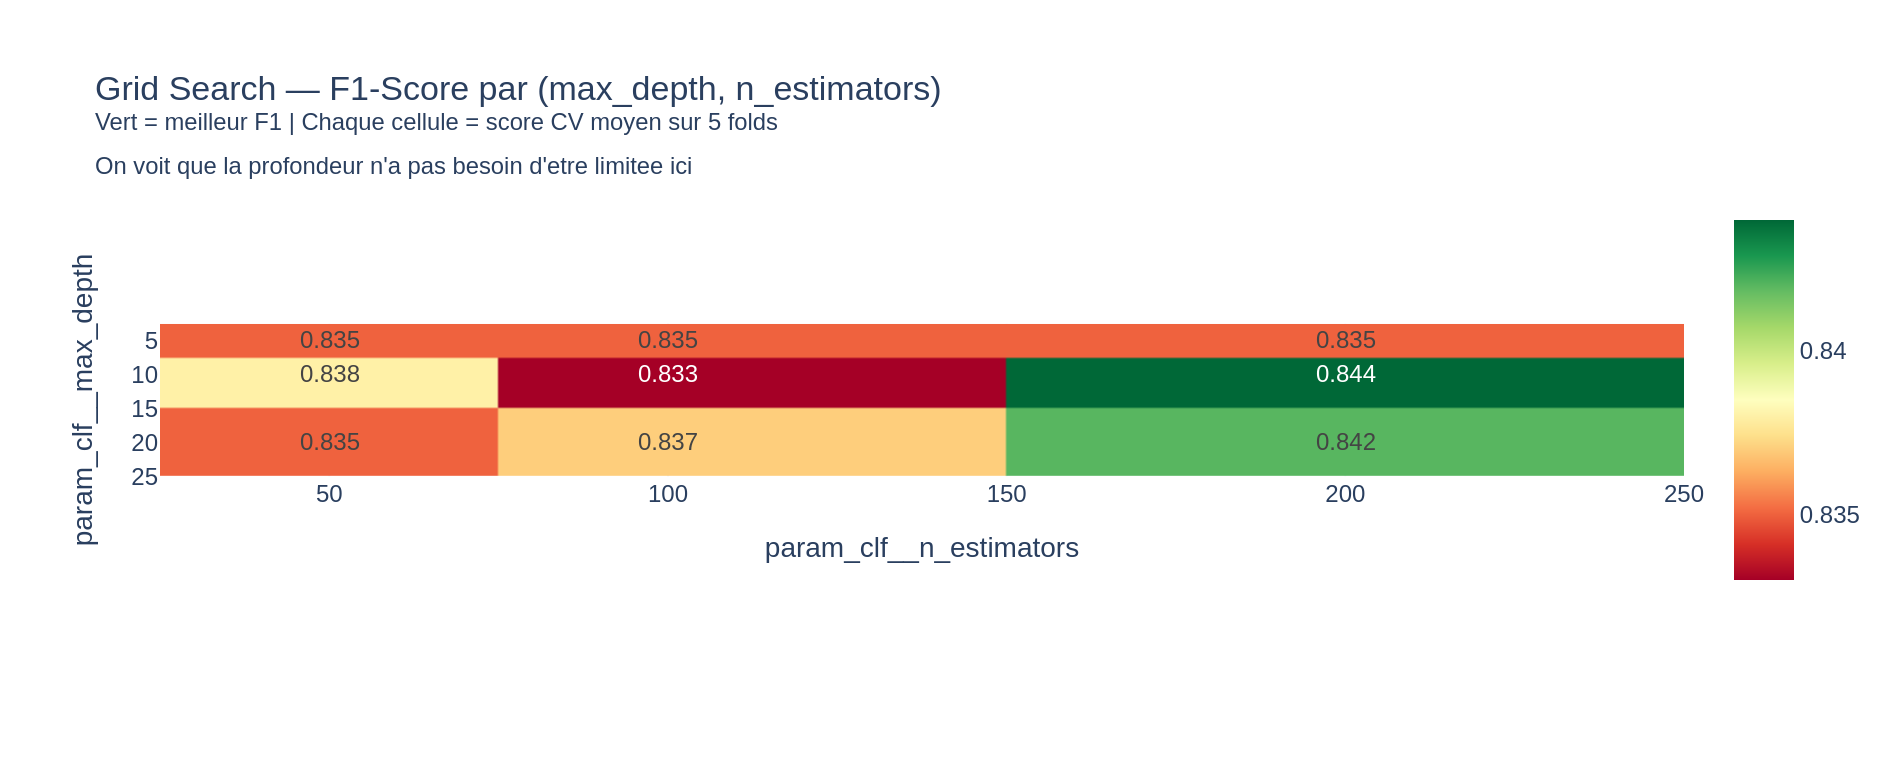

In [18]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

rf_base = Pipeline([("sc",StandardScaler()),
                    ("clf",RandomForestClassifier(random_state=42))])

param_grid = {
    "clf__n_estimators":      [50,100,200],
    "clf__max_depth":         [None,5,10,20],
    "clf__min_samples_split": [2,5],
}
print("Grid Search — exploration exhaustive")
print(f"  {3*4*2} combinaisons x 5 folds = 120 entrainements\n")

grid = GridSearchCV(rf_base,param_grid,cv=5,scoring="f1",n_jobs=-1)
grid.fit(X_tr_m,y_tr_m)
print(f"Meilleure config  : {grid.best_params_}")
print(f"Meilleur F1 (CV)  : {grid.best_score_:.4f}")

results_df = pd.DataFrame(grid.cv_results_)
pivot = results_df.pivot_table(
    values="mean_test_score",
    index="param_clf__max_depth",
    columns="param_clf__n_estimators",
    aggfunc="mean")

fig = px.imshow(pivot.round(3),text_auto=True,color_continuous_scale="RdYlGn",
    title="Grid Search — F1-Score par (max_depth, n_estimators)<br>"
          "<sup>Vert = meilleur F1 | Chaque cellule = score CV moyen sur 5 folds<br>"
          "On voit que la profondeur n'a pas besoin d'etre limitee ici</sup>")
fig.update_layout(height=380,template="plotly_white")
fig.show()

In [ ]:
param_dist = {
    "clf__n_estimators":      randint(50,500),
    "clf__max_depth":         [None,5,10,15,20,30],
    "clf__min_samples_split": randint(2,20),
    "clf__min_samples_leaf":  randint(1,10),
    "clf__max_features":      ["sqrt","log2",0.3,0.5],
}
print("Random Search — 30 iterations aleatoires")
rand_search = RandomizedSearchCV(rf_base,param_dist,n_iter=30,
    cv=5,scoring="f1",random_state=42,n_jobs=-1)
rand_search.fit(X_tr_m,y_tr_m)
print(f"Meilleure config  : {rand_search.best_params_}")
print(f"Meilleur F1 (CV)  : {rand_search.best_score_:.4f}")
print()
print(f"Comparaison :")
print(f"  Grid Search   : F1 = {grid.best_score_:.4f}")
print(f"  Random Search : F1 = {rand_search.best_score_:.4f}")
print()
print("Random Search trouve souvent un resultat comparable en 5-10x moins de temps.")

Random Search — 30 iterations aleatoires


In [ ]:
best_rf = grid.best_estimator_
tr_sizes = np.linspace(0.1,1.0,10)
trs,tr_sc,val_sc = learning_curve(best_rf,X_m,y_m,cv=5,scoring="f1",
    train_sizes=tr_sizes,n_jobs=-1)
tr_m,tr_s = tr_sc.mean(1),tr_sc.std(1)
val_m,val_s= val_sc.mean(1),val_sc.std(1)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=np.concatenate([trs,trs[::-1]]),
    y=np.concatenate([tr_m+tr_s,(tr_m-tr_s)[::-1]]),
    fill="toself",fillcolor="rgba(233,69,96,0.15)",line=dict(width=0),showlegend=False))
fig.add_trace(go.Scatter(
    x=np.concatenate([trs,trs[::-1]]),
    y=np.concatenate([val_m+val_s,(val_m-val_s)[::-1]]),
    fill="toself",fillcolor="rgba(15,52,96,0.15)",line=dict(width=0),showlegend=False))
fig.add_trace(go.Scatter(x=trs,y=tr_m,mode="lines+markers",name="F1 Train",
    line=dict(color=COLORS["primary"],width=2.5)))
fig.add_trace(go.Scatter(x=trs,y=val_m,mode="lines+markers",name="F1 Validation CV",
    line=dict(color=COLORS["secondary"],width=2.5)))
fig.update_layout(
    title="Courbes d'apprentissage — Comment diagnostiquer overfitting/underfitting ?<br>"
          "<sup>Si Train >> Validation = overfitting (trop complexe, besoin de regularisation)<br>"
          "Si Train ≈ Validation ≈ bas = underfitting (trop simple, besoin d'un modele plus riche)<br>"
          "Si Train ≈ Validation (hauts et proches) = bon modele<br>"
          "Zones colorees = +/- 1 ecart-type entre les 5 folds</sup>",
    xaxis_title="Nb d'exemples d'entrainement",yaxis_title="F1-Score",
    height=430,template="plotly_white")
fig.show()
gap = (tr_m-val_m)[-1]
diag = "Bon equilibre" if gap<0.05 else ("Legere tendance overfitting" if gap<0.15 else "Overfitting")
print(f"Ecart final Train-Validation : {gap:.3f} → {diag}")

---
<div style="background:linear-gradient(90deg,#16a085,#0e7c63);padding:18px 24px;border-radius:10px;color:white;margin:20px 0;">
<h1 style="margin:0;">🔗 Pipelines Scikit-Learn — Industrialiser son Code ML</h1>
</div>

## Pourquoi utiliser des Pipelines ?

Jusqu'ici on a écrit des étapes séparées : `StandardScaler().fit_transform(X)` puis `model.fit(X_scaled, y)`. Cette approche a un piège sérieux : le **data leakage** (fuite de données).

### Le problème du Data Leakage

Si on standardise (`StandardScaler`) sur **tout** le dataset avant de séparer train/test, les statistiques (moyenne, écart-type) du test set ont influencé la transformation du train set. Le modèle a donc indirectement "vu" des informations du test avant l'évaluation — les performances mesurées sont **trop optimistes** et ne reflètent pas la réalité en production.

```
❌ INCORRECT (fuite de données) :
   X_scaled = StandardScaler().fit_transform(X)        # vu TOUT X, y compris le futur test
   X_train, X_test = train_test_split(X_scaled, ...)

✅ CORRECT (avec Pipeline) :
   X_train, X_test = train_test_split(X, ...)            # split AVANT tout traitement
   pipeline.fit(X_train, y_train)                        # scaler appris UNIQUEMENT sur train
   pipeline.predict(X_test)                               # test transformé avec stats du train
```

### Ce qu'un Pipeline automatise

Un `Pipeline` scikit-learn enchaîne plusieurs étapes (`transformers` + `estimator` final) et garantit que :
- Chaque étape est apprise (`fit`) uniquement sur les données d'entraînement
- La même séquence de transformations s'applique automatiquement en prédiction
- `GridSearchCV` et `cross_val_score` appliquent le pipeline complet à chaque fold — zéro fuite possible

---

## ColumnTransformer — traiter différemment les colonnes numériques et catégorielles

En pratique, un dataset mélange souvent des colonnes numériques (âge, prix) et catégorielles (ville, catégorie). Chaque type a besoin d'un traitement différent :
- **Numériques** : imputation des valeurs manquantes (médiane) + normalisation (`StandardScaler`)
- **Catégorielles** : imputation (valeur la plus fréquente) + encodage (`OneHotEncoder`)

`ColumnTransformer` applique le bon traitement à la bonne colonne, **en parallèle**, puis concatène le résultat — le tout reste un objet unique qu'on peut mettre dans un `Pipeline`.


In [ ]:
# ── Dataset volontairement "sale" : mix numérique + catégoriel + valeurs manquantes ──
np.random.seed(7)
n_p = 600

villes      = np.random.choice(["Marseille","Paris","Lyon","Toulouse","Nantes"], n_p,
                                 p=[0.3,0.25,0.2,0.15,0.1])
type_bien   = np.random.choice(["Appartement","Maison","Studio"], n_p, p=[0.5,0.3,0.2])
surface     = np.random.normal(65, 30, n_p).clip(15, 250)
etage       = np.random.randint(0, 10, n_p).astype(float)
annee_const = np.random.randint(1950, 2024, n_p).astype(float)

# Prix dépend de la ville, surface, type — avec un peu de bruit
prix_base = {"Marseille":2800,"Paris":9500,"Lyon":4200,"Toulouse":3000,"Nantes":3300}
type_mult = {"Appartement":1.0,"Maison":1.25,"Studio":0.85}
prix_m2 = np.array([prix_base[v]*type_mult[t] for v,t in zip(villes,type_bien)])
prix    = (prix_m2 * surface * np.random.normal(1,0.12,n_p)).round(0)

df_immo = pd.DataFrame({
    "ville": villes, "type_bien": type_bien, "surface_m2": surface,
    "etage": etage, "annee_construction": annee_const, "prix": prix,
})

# Injecter volontairement des valeurs manquantes (réaliste !)
for col, frac in [("surface_m2",0.04), ("etage",0.08), ("annee_construction",0.06)]:
    idx = np.random.choice(n_p, int(n_p*frac), replace=False)
    df_immo.loc[idx, col] = np.nan

print(f"Dataset immobilier : {len(df_immo)} biens, {df_immo.isna().sum().sum()} valeurs manquantes")
print(df_immo.isna().sum())
df_immo.head(8)


In [ ]:
# ── Construction du Pipeline complet avec ColumnTransformer ──
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

num_features = ["surface_m2", "etage", "annee_construction"]
cat_features = ["ville", "type_bien"]

# Sous-pipeline pour les colonnes numériques
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# Sous-pipeline pour les colonnes catégorielles
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

# ColumnTransformer applique le bon pipeline à la bonne colonne
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features),
])

# Pipeline final : preprocessing + modèle, comme un seul objet
full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(n_estimators=150, max_depth=4, random_state=42)),
])

X_immo = df_immo.drop(columns="prix")
y_immo = df_immo["prix"]

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(X_immo, y_immo, test_size=0.2, random_state=42)

# Une seule ligne pour TOUT entraîner — imputation, encodage, scaling, modèle
full_pipeline.fit(X_tr_i, y_tr_i)
y_pred_i = full_pipeline.predict(X_te_i)

mape_i = np.mean(np.abs((y_te_i - y_pred_i) / y_te_i)) * 100
r2_i   = r2_score(y_te_i, y_pred_i)

print(f"Pipeline complet — Prix immobilier")
print(f"  R²   : {r2_i:.3f}")
print(f"  MAPE : {mape_i:.1f}%")
print()
print("Avantage : full_pipeline.predict(nouveau_bien) applique automatiquement")
print("imputation + encodage + scaling + prédiction — même sur des valeurs manquantes")
print("ou des villes inconnues (grâce à handle_unknown='ignore').")


In [ ]:
# ── Visualisation : le pipeline gère nativement les valeurs manquantes ──
nouveau_bien = pd.DataFrame({
    "ville":["Marseille"], "type_bien":["Appartement"],
    "surface_m2":[np.nan],   # valeur manquante volontaire !
    "etage":[3.0], "annee_construction":[2005.0],
})
prediction = full_pipeline.predict(nouveau_bien)[0]
print(f"Bien avec surface MANQUANTE → prix prédit : {prediction:,.0f} €")
print("(le pipeline a automatiquement imputé la surface par la médiane apprise sur le train)")
print()

# Importance des features après preprocessing
ohe = full_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"]
cat_names = list(ohe.get_feature_names_out(cat_features))
all_names = num_features + cat_names
importances_immo = pd.Series(
    full_pipeline.named_steps["model"].feature_importances_, index=all_names
).sort_values(ascending=True)

fig = go.Figure(go.Bar(
    x=importances_immo.values, y=importances_immo.index, orientation="h",
    marker=dict(color=importances_immo.values, colorscale="Tealgrn", showscale=False)))
fig.update_layout(
    title="Importance des features après ColumnTransformer<br>"
          "<sup>surface_m2 domine — logique : c'est le facteur n°1 du prix au m²<br>"
          "Chaque ville encodée individuellement (OneHotEncoder) montre son poids propre</sup>",
    height=420, template="plotly_white")
fig.show()

print("Comparaison Pred vs Réel sur le test set :")
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=y_te_i, y=y_pred_i, mode="markers",
    marker=dict(color=COLORS["primary"], size=6, opacity=0.5)))
fig2.add_trace(go.Scatter(x=[y_immo.min(),y_immo.max()], y=[y_immo.min(),y_immo.max()],
    mode="lines", line=dict(color="black", dash="dash")))
fig2.update_layout(title=f"Pipeline immobilier — R²={r2_i:.3f} | MAPE={mape_i:.1f}%",
    xaxis_title="Prix réel (€)", yaxis_title="Prix prédit (€)",
    height=380, template="plotly_white", showlegend=False)
fig2.show()


---
<div style="background:linear-gradient(90deg,#ff6b35,#e67e22);padding:18px 24px;border-radius:10px;color:#1a1a2e;margin:20px 0;">
<h1 style="margin:0;">🤗 Partie 10 — Fine-Tuning HuggingFace Transformers</h1>
</div>

## Du ML classique aux Transformers

Scikit-Learn excelle sur les **donnees tabulaires**. Pour le **texte avance, les images, l'audio**, les architectures Transformer sont l'etat de l'art.

### Transfer Learning : reutiliser ce qu'un modele a deja appris

BERT a ete pre-entraine sur des milliards de phrases et a appris la langue.
On prend ce modele et on l'adapte a notre tache avec seulement quelques centaines d'exemples.

**Avantage majeur :** 500 exemples avec BERT > 100 000 exemples avec TF-IDF sur du texte complexe.

### LoRA : fine-tuner sans GPU de data center

Un LLM a des milliards de parametres. LoRA ajoute de petites matrices de rang faible.
Au lieu de modifier 7 milliards de parametres, on en entraine 10-50 millions seulement.

**QLoRA = LoRA + quantification 4-bit** : fine-tuner un 7B sur un GPU grand public (16GB VRAM).

In [ ]:
# ── Fine-tuning HuggingFace — Exemple complet sur sentiment ──
# pip install transformers datasets torch accelerate

try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    from datasets import Dataset
    import torch
    HF_AVAILABLE = True
    print(f"HuggingFace disponible — torch {torch.__version__}")
except ImportError:
    HF_AVAILABLE = False
    print("HuggingFace non installe — installer : pip install transformers datasets torch")

# Le code ci-dessous montre la structure du fine-tuning
# Il s'execute si HuggingFace est installe

print()
print("ETAPES DU FINE-TUNING :")
print()
print("1. CHARGER UN MODELE PRE-ENTRAINE")
print("   model_name = 'distilbert-base-multilingual-cased'")
print("   tokenizer  = AutoTokenizer.from_pretrained(model_name)")
print("   model      = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)")
print()
print("2. PREPARER LE DATASET")
print("   dataset = Dataset.from_dict({'text': feedbacks, 'label': sentiments})")
print("   dataset = dataset.train_test_split(test_size=0.25)")
print("   tok_ds  = dataset.map(lambda x: tokenizer(x['text'], truncation=True, padding=True))")
print()
print("3. CONFIGURER L'ENTRAINEMENT")
print("   from transformers import TrainingArguments, Trainer")
print("   training_args = TrainingArguments(")
print("       output_dir='./finetuned',")
print("       num_train_epochs=3,")
print("       per_device_train_batch_size=4,")
print("       evaluation_strategy='epoch',")
print("   )")
print()
print("4. LANCER")
print("   trainer = Trainer(model=model, args=training_args,")
print("       train_dataset=tok_ds['train'], eval_dataset=tok_ds['test'])")
print("   trainer.train()")
print()
print("5. INFERENCE")
print("   from transformers import pipeline")
print("   classifier = pipeline('text-classification', model=model, tokenizer=tokenizer)")
print("   result = classifier('Ce produit est excellent!')")
print("   # -> [{'label': 'LABEL_1', 'score': 0.97}]")

if HF_AVAILABLE:
    print()
    print("HuggingFace detecte — vous pouvez executer le code ci-dessus directement.")
    print("Attention : le fine-tuning necessite ~10-30 min selon votre machine.")


---
<div style="background:linear-gradient(135deg,#1a1a2e,#16213e);padding:30px;border-radius:12px;color:white;">
<h2 style="color:#e94560;">Synthese — Choisir le bon algorithme et la bonne metrique</h2>

| Probleme | Volume | Algorithme | Metrique cle |
|---|---|---|---|
| Regression tabulaire | < 500k | Random Forest / GBM | RMSE + R2 |
| Regression lineaire | Tout | Ridge / Lasso | R2 + MAE |
| Classification equilibree | Tout | GBM + calibration | Accuracy + AUC |
| Classification desequilibree | Tout | Random Forest + seuil | F1 + Rappel |
| Segmentation | < 1M | K-Means + silhouette | Silhouette + metier |
| Anomalies sans labels | Tout | Isolation Forest | Rappel + Precision |
| Texte basique | < 100k | TF-IDF + LogReg | F1 |
| Texte avance | Tout | CamemBERT / fine-tuning | F1 + Accuracy |
| Serie temporelle | Tout | GBM + features lag | MAPE |
| Vision / Audio | Tout | Transformer + fine-tuning | Task-specific |

<h3 style="color:#a8dadc;">Ressources</h3>
<ul style="font-size:.9em;">
<li>Scikit-Learn : https://scikit-learn.org/stable/user_guide.html</li>
<li>HuggingFace  : https://huggingface.co/docs</li>
<li>Optuna       : https://optuna.org</li>
<li>Plotly Python: https://plotly.com/python/</li>
<li>Kaggle Learn : https://www.kaggle.com/learn</li>
</ul>
</div>

---
<div style="background:linear-gradient(135deg,#2c3e50,#1a1a2e);padding:30px;border-radius:14px;color:white;margin:30px 0;">
<h1 style="margin:0;color:#ffc864;">🏋️ Exercices de Mise en Pratique</h1>
<p style="color:#ccc;margin-top:10px;">4 défis avec des données réelles ou amusantes — à vous de coder !</p>
</div>

Chaque exercice fournit le dataset et l'objectif. Le code de chargement des données est fourni ; à vous de construire le pipeline, entraîner le modèle, et visualiser les résultats. Une solution indicative est cachée en dessous de chaque exercice (à ne consulter qu'après avoir essayé).


## 🎯 Exercice 1 — Pokémon : prédire si un Pokémon est légendaire

**Dataset :** statistiques de 800 Pokémon (attaque, défense, vitesse, types...).

**Objectif :** entraîner un classifieur pour détecter les Pokémon légendaires à partir de leurs statistiques de combat.

**Étapes à coder :**
1. Séparer features (stats numériques) et target (`legendary`)
2. Split train/test stratifié (les légendaires sont rares !)
3. Pipeline avec `StandardScaler` + `RandomForestClassifier`
4. Évaluer avec F1-score (classes déséquilibrées)
5. Visualiser : quelles stats trahissent un légendaire ?

**Indice :** un Pokémon légendaire a généralement des stats totales très élevées, mais ce n'est pas le seul facteur — le modèle peut découvrir des patterns plus subtils.


In [ ]:
# ── EXERCICE 1 : Données Pokémon (générées avec distribution réaliste) ──
np.random.seed(11)
n_poke = 800
n_legend = 65

types_poke = ["Feu","Eau","Plante","Électrik","Psy","Dragon","Normal","Combat","Vol","Ténèbres"]

def gen_pokemon(n, legendary=False):
    if legendary:
        # Les légendaires ont des stats globalement plus hautes et plus de variance
        atk  = np.random.normal(115, 25, n).clip(50, 190)
        defe = np.random.normal(105, 28, n).clip(40, 190)
        spd  = np.random.normal(100, 30, n).clip(30, 180)
        hp   = np.random.normal(95, 22, n).clip(50, 160)
        spatk= np.random.normal(120, 28, n).clip(50, 194)
    else:
        atk  = np.random.normal(72, 25, n).clip(5, 150)
        defe = np.random.normal(68, 24, n).clip(5, 150)
        spd  = np.random.normal(65, 22, n).clip(5, 140)
        hp   = np.random.normal(65, 20, n).clip(10, 130)
        spatk= np.random.normal(65, 24, n).clip(10, 150)
    return pd.DataFrame({
        "hp":hp, "attack":atk, "defense":defe,
        "sp_atk":spatk, "speed":spd,
        "type_principal": np.random.choice(types_poke, n),
        "legendary": int(legendary),
    })

df_poke = pd.concat([
    gen_pokemon(n_poke - n_legend, legendary=False),
    gen_pokemon(n_legend, legendary=True),
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset Pokémon : {len(df_poke)} Pokémon, {df_poke['legendary'].sum()} légendaires "
      f"({df_poke['legendary'].mean()*100:.1f}%)")
df_poke.head(8)

# ─────────────────────────────────────────────────────────
# 👉 À VOUS : compléter le code ci-dessous
# ─────────────────────────────────────────────────────────
# X_poke = df_poke.drop(columns="legendary")
# y_poke = df_poke["legendary"]
# X_tr, X_te, y_tr, y_te = train_test_split(X_poke, y_poke, test_size=0.2,
#                                             stratify=y_poke, random_state=42)
# ... construire le ColumnTransformer (numérique vs type_principal) ...
# ... pipeline avec RandomForestClassifier ...
# ... fit, predict, f1_score ...


<details>
<summary><b>💡 Voir une solution indicative</b></summary>

```python
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X_poke = df_poke.drop(columns="legendary")
y_poke = df_poke["legendary"]
X_tr, X_te, y_tr, y_te = train_test_split(X_poke, y_poke, test_size=0.2,
                                            stratify=y_poke, random_state=42)

num_cols = ["hp","attack","defense","sp_atk","speed"]
cat_cols = ["type_principal"]

preproc = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])
pipe_poke = Pipeline([
    ("prep", preproc),
    ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42))
])
pipe_poke.fit(X_tr, y_tr)
y_pred = pipe_poke.predict(X_te)
print(f"F1-score : {f1_score(y_te, y_pred):.3f}")
```
</details>


---
## 🍷 Exercice 2 — Vins : clustering par profil chimique

**Dataset :** composition chimique de vins (acidité, alcool, sucre résiduel, sulfites...).

**Objectif :** regrouper les vins en clusters de profils similaires SANS connaître leur appellation à l'avance, puis visualiser si les clusters trouvés correspondent à des catégories logiques.

**Étapes à coder :**
1. Standardiser les variables chimiques
2. Tester K=2 à K=6 avec le score de silhouette
3. Appliquer K-Means avec le meilleur K
4. Réduire en 2D avec PCA pour visualiser les clusters
5. Comparer avec les vraies catégories (rouge/blanc/rosé) — le clustering les retrouve-t-il ?

**Indice :** les vins rouges et blancs ont des profils chimiques très différents (tanins, couleur, sucre) — un bon clustering devrait naturellement les séparer.


In [ ]:
# ── EXERCICE 2 : Données vins (générées avec profils chimiques réalistes) ──
np.random.seed(22)
n_wine = 500

def gen_wine(n, category):
    profiles = {
        "Rouge": {"acidite":[7.5,1.2], "alcool":[13.2,1.0], "sucre":[2.5,1.0],
                  "sulfites":[0.6,0.2], "tanins":[0.7,0.15]},
        "Blanc": {"acidite":[6.8,1.0], "alcool":[11.5,1.1], "sucre":[5.5,3.0],
                  "sulfites":[0.4,0.15], "tanins":[0.1,0.05]},
        "Rose":  {"acidite":[7.0,0.9], "alcool":[12.0,0.8], "sucre":[3.5,1.5],
                  "sulfites":[0.45,0.12], "tanins":[0.3,0.1]},
    }
    p = profiles[category]
    return pd.DataFrame({
        "acidite":  np.random.normal(*p["acidite"], n).clip(4,10),
        "alcool":   np.random.normal(*p["alcool"], n).clip(8,16),
        "sucre":    np.random.normal(*p["sucre"], n).clip(0.5,20),
        "sulfites": np.random.normal(*p["sulfites"], n).clip(0.1,1.2),
        "tanins":   np.random.normal(*p["tanins"], n).clip(0.02,1.0),
        "categorie_reelle": category,
    })

df_wine = pd.concat([
    gen_wine(220, "Rouge"), gen_wine(200, "Blanc"), gen_wine(80, "Rose")
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset vins : {len(df_wine)} échantillons")
print(df_wine["categorie_reelle"].value_counts())
df_wine.head(8)

# ─────────────────────────────────────────────────────────
# 👉 À VOUS : compléter le code ci-dessous
# ─────────────────────────────────────────────────────────
# X_wine = df_wine.drop(columns="categorie_reelle")
# Xs_wine = StandardScaler().fit_transform(X_wine)
# ... tester silhouette pour K=2..6 ...
# ... KMeans avec meilleur K ...
# ... PCA 2D pour visualiser ...
# ... comparer cluster vs categorie_reelle (crosstab) ...


<details>
<summary><b>💡 Voir une solution indicative</b></summary>

```python
X_wine  = df_wine.drop(columns="categorie_reelle")
Xs_wine = StandardScaler().fit_transform(X_wine)

silhouettes = []
for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(Xs_wine)
    silhouettes.append(silhouette_score(Xs_wine, lbl))
best_k = range(2,7)[np.argmax(silhouettes)]

km_wine = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = km_wine.fit_predict(Xs_wine)

pca_wine = PCA(n_components=2)
X2_wine  = pca_wine.fit_transform(Xs_wine)

fig = px.scatter(x=X2_wine[:,0], y=X2_wine[:,1], color=df_wine["categorie_reelle"],
                 symbol=clusters.astype(str),
                 title="Clusters trouvés (symbole) vs vraies catégories (couleur)")
fig.show()

print(pd.crosstab(clusters, df_wine["categorie_reelle"]))
```
</details>


---
## 🎬 Exercice 3 — Films : prédire la note IMDB

**Dataset :** caractéristiques de films (budget, durée, année, genre, nombre de votes...).

**Objectif :** prédire la note IMDB d'un film à partir de ses caractéristiques de production, et identifier quels facteurs influencent le plus la note.

**Étapes à coder :**
1. Pipeline complet (ColumnTransformer numérique + catégoriel pour le genre)
2. Comparer 3 modèles : LinearRegression, RandomForest, GradientBoosting
3. Cross-validation 5-fold pour choisir le meilleur
4. Visualiser l'importance des features sur le meilleur modèle
5. Tracer Prédit vs Réel avec une ligne idéale

**Indice :** le nombre de votes est souvent très corrélé à la note dans ce genre de données — un film obscur a peu de votes ; un blockbuster bien noté en a énormément. Attention à ne pas confondre corrélation et causalité !


In [ ]:
# ── EXERCICE 3 : Données films (générées avec patterns réalistes) ──
np.random.seed(33)
n_films = 700

genres = ["Action","Comédie","Drame","Horreur","Animation","SF","Romance"]
genre_film = np.random.choice(genres, n_films, p=[0.2,0.18,0.22,0.1,0.1,0.12,0.08])
budget_m   = np.random.lognormal(3.0, 1.1, n_films).clip(0.5, 300)   # millions $
duree_min  = np.random.normal(108, 20, n_films).clip(75, 195)
annee      = np.random.randint(1990, 2025, n_films)
nb_votes_k = (np.random.lognormal(4.5, 1.3, n_films)).clip(0.5, 2000)  # milliers de votes

genre_bonus = {"Drame":0.4,"Animation":0.3,"SF":0.1,"Action":-0.1,
               "Comédie":0.0,"Horreur":-0.3,"Romance":0.05}
note = (6.3
        + np.array([genre_bonus[g] for g in genre_film])
        + 0.35*np.log1p(nb_votes_k)/3
        - 0.15*(budget_m>150).astype(float)        # très gros budgets parfois décevants
        + np.random.normal(0,0.5,n_films)
       ).clip(2.5, 9.5).round(1)

df_films = pd.DataFrame({
    "genre": genre_film, "budget_millions": budget_m.round(1),
    "duree_min": duree_min.round(0), "annee": annee,
    "nb_votes_milliers": nb_votes_k.round(1), "note_imdb": note,
})

print(f"Dataset films : {len(df_films)} films, note moyenne {df_films['note_imdb'].mean():.2f}")
df_films.head(8)

# ─────────────────────────────────────────────────────────
# 👉 À VOUS : compléter le code ci-dessous
# ─────────────────────────────────────────────────────────
# X_films = df_films.drop(columns="note_imdb")
# y_films = df_films["note_imdb"]
# ... ColumnTransformer (numérique: budget/duree/annee/votes, catégoriel: genre) ...
# ... comparer LinearRegression / RandomForestRegressor / GradientBoostingRegressor ...
# ... cross_val_score cv=5 scoring='r2' pour chaque modèle ...
# ... entraîner le meilleur sur tout le train, visualiser importance + pred vs réel ...


<details>
<summary><b>💡 Voir une solution indicative</b></summary>

```python
from sklearn.ensemble import RandomForestRegressor

X_films = df_films.drop(columns="note_imdb")
y_films = df_films["note_imdb"]
X_tr, X_te, y_tr, y_te = train_test_split(X_films, y_films, test_size=0.2, random_state=42)

num_f = ["budget_millions","duree_min","annee","nb_votes_milliers"]
cat_f = ["genre"]
preproc = ColumnTransformer([
    ("num", StandardScaler(), num_f),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_f),
])

models_f = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=150, random_state=42),
    "GBM": GradientBoostingRegressor(n_estimators=150, random_state=42),
}
for name, m in models_f.items():
    pipe = Pipeline([("prep",preproc),("model",m)])
    cv = cross_val_score(pipe, X_films, y_films, cv=5, scoring="r2")
    print(f"{name:<15} R² CV = {cv.mean():.3f} (±{cv.std():.3f})")
```
</details>


---
## 🎵 Exercice 4 — Musique : détecter des morceaux "hit potentiel"

**Dataset :** caractéristiques audio de morceaux (tempo, énergie, dansabilité, durée, popularité passée de l'artiste...).

**Objectif :** classifier si un morceau a un fort potentiel de hit, et visualiser l'espace des morceaux en 2D pour repérer les zones "à fort potentiel".

**Étapes à coder :**
1. Pipeline avec gestion du déséquilibre des classes (`class_weight="balanced"`)
2. Entraîner un Gradient Boosting Classifier
3. Tracer la courbe ROC et calculer l'AUC
4. Réduire en 2D avec PCA et colorer par probabilité de hit prédite
5. Identifier les 10 morceaux avec la plus forte probabilité de hit dans le test set

**Indice :** dans la vraie vie du Music Information Retrieval, la dansabilité et l'énergie sont des signaux forts, mais ce n'est jamais suffisant — la "magie" d'un hit reste partiellement imprévisible, ce qui est aussi un bon résultat pédagogique sur les limites du ML !


In [ ]:
# ── EXERCICE 4 : Données musicales (générées avec patterns réalistes) ──
np.random.seed(44)
n_tracks = 900
n_hits   = 110

def gen_tracks(n, hit):
    if hit:
        dansabilite = np.random.normal(0.72, 0.12, n).clip(0,1)
        energie     = np.random.normal(0.68, 0.15, n).clip(0,1)
        tempo       = np.random.normal(118, 12, n).clip(60,200)
        duree_s     = np.random.normal(195, 25, n).clip(120,330)
        popularite_artiste = np.random.normal(65, 20, n).clip(0,100)
    else:
        dansabilite = np.random.normal(0.52, 0.18, n).clip(0,1)
        energie     = np.random.normal(0.50, 0.20, n).clip(0,1)
        tempo       = np.random.normal(110, 22, n).clip(50,210)
        duree_s     = np.random.normal(220, 50, n).clip(90,420)
        popularite_artiste = np.random.normal(35, 22, n).clip(0,100)
    return pd.DataFrame({
        "dansabilite": dansabilite, "energie": energie, "tempo_bpm": tempo,
        "duree_sec": duree_s, "popularite_artiste": popularite_artiste,
        "hit": int(hit),
    })

df_music = pd.concat([
    gen_tracks(n_tracks-n_hits, hit=False), gen_tracks(n_hits, hit=True)
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset musical : {len(df_music)} morceaux, {df_music['hit'].sum()} hits "
      f"({df_music['hit'].mean()*100:.1f}%)")
df_music.head(8)

# ─────────────────────────────────────────────────────────
# 👉 À VOUS : compléter le code ci-dessous
# ─────────────────────────────────────────────────────────
# X_music = df_music.drop(columns="hit")
# y_music = df_music["hit"]
# ... split stratifié, pipeline StandardScaler + GradientBoostingClassifier ...
# ... courbe ROC + AUC ...
# ... PCA 2D colorée par probabilité prédite (predict_proba) ...
# ... top 10 morceaux du test set par probabilité de hit ...


<details>
<summary><b>💡 Voir une solution indicative</b></summary>

```python
X_music = df_music.drop(columns="hit")
y_music = df_music["hit"]
X_tr, X_te, y_tr, y_te = train_test_split(X_music, y_music, test_size=0.2,
                                            stratify=y_music, random_state=42)

pipe_music = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", GradientBoostingClassifier(n_estimators=150, random_state=42))
])
pipe_music.fit(X_tr, y_tr)
y_prob = pipe_music.predict_proba(X_te)[:,1]

fpr, tpr, _ = roc_curve(y_te, y_prob)
print(f"AUC : {auc(fpr,tpr):.3f}")

pca_m = PCA(n_components=2)
X2_m  = pca_m.fit_transform(StandardScaler().fit_transform(X_music))
fig = px.scatter(x=X2_m[:,0], y=X2_m[:,1],
                 color=pipe_music.predict_proba(X_music)[:,1],
                 color_continuous_scale="RdYlGn", title="Probabilité de hit en 2D (PCA)")
fig.show()

top10 = X_te.copy()
top10["proba_hit"] = y_prob
print(top10.sort_values("proba_hit", ascending=False).head(10))
```
</details>
